# Comparison Between using a Projection Matrix and Introduction of Slack Variables to Handle Infeasibility in QUT Methodology

Linear optimization is a powerful tool to minimize or maximize an objective function given a system of linear equations and constraints. In our case, the strict constraint is $\lambda_{\max}=\min_{\boldsymbol{w}\in\mathbb{R}^{m}}\|\boldsymbol{w}\|_{\infty}\quad\text{subject to}\quad D^{\mathsf T}\boldsymbol{w}=\boldsymbol{g}$. The $D^{\mathsf T}\boldsymbol{w}=\boldsymbol{g}$ constraint can become troublesome because it is feasible only when $\boldsymbol{g}$ lies in the column space of $D^{\mathsf T}$; even a small numerical residual outside this space can cause infeasibility. To handle this, we can use a projection matrix that utilizes the **Moore-Penrose inverse** to project the gradient $\boldsymbol{g}$, or equivalently $X^{\mathsf T}(y-p)$, onto the column space of $D^{\mathsf T}$, or we can introduce a small, uniform slack term per sector $\epsilon$ that modifies the constraint to an inequality represented as $|D^{\mathsf T}\boldsymbol{w}-\boldsymbol{g}| \leq \epsilon$. Both methods account for any non-representable constant component of the gradient. This notebook will describe the difference between the two methods, but first we must describe the method from the bottom up and introduce both solutions when using the **Quantile Universal Threshold (QUT)** method to estimate $\lambda$. 

## 1. Null Logistic Regression

Within the context of TV-smoothing we use the above optimization problem to solve for $\lambda_{\max}$, the smallest penalty term that drives the differences between sector coefficients to zero under the null hypothesis that each sector contributes equally to threat propensity, so only how many sectors you visit matters, not which sectors. To accomplish this, we use the movement design $X \in \mathbb{R}^{n \times p}$, where each independent variable is a sector on the court, $n$ is the number of observations, and $y \in \{0,1\}^{n}$ is the response vector. We collapse the design matrix $X$ into a single predictor $X_0 = X\boldsymbol{1}_p$ to get the number of sectors visited per possession, then fit a one-predictor logistic model to obtain $\hat{\beta}_0$. Using $\hat{\beta}_0$ and $X\boldsymbol{1}_p$, we can use sigmoid to generate null probabilities for each possession, followed by vector notation:

\begin{aligned}
\ p_i^{(0)} = \frac{1}{1+\exp[-(X_0)_i\hat{\beta}_0]}
\\
\ p^0 = \sigma(X_0\hat{\beta}_0)
\end{aligned}

As an example calculation, let $X_0 = X\boldsymbol{1}_p = 40$ and $\hat{\beta}_0 = .001$, where 40 represents how many sectors we have visited.

\begin{aligned}
\ p^0_1 = \sigma(40 \cdot .001) \approx 0.51
\end{aligned}

This operation is completed for every possession. Because of the nature of sigmoid, the calculated probabilities are likely going to be similar values when $\hat{\beta}_0$ is close to zero. If we were to change $X_0 = X\boldsymbol{1}_p = 120$ and keep $\hat{\beta}_0 = .001$, we would get the following probability:

\begin{aligned}
\ p^0_2 = \sigma(120 \cdot .001) \approx 0.53
\end{aligned}

When comparing $p^0_1$ to $p^0_2$, tripling the amount of sectors visited results in approximately a two-percentage-point increase in probability of scoring. This property will become important in the next few sections where we calculate the **null likelihood gradient**.

## 2. Null Log-Likelihood Gradient

The null likelihood gradient represents the contribution each sector has under the null hypothesis. When the scalar null model is fitted, its score equation ensures that the entries of the gradient sum to zero, apart from a possible small numerical residual. The calculation is shown below.

\begin{aligned}
\boldsymbol{g} = \operatorname{grad}_h = X^{\mathsf T}(y-p^0),
\qquad \boldsymbol{g}\in\mathbb{R}^{p}.
\end{aligned}

For clarity, below is a toy example with three observations and four sectors, where $y^{\mathsf T}=(1,0,1)$ and $X_0=X\boldsymbol{1}_4=(3,2,4)^{\mathsf T}$. Fitting the scalar null model gives $\hat{\beta}_0\approx0.39711$ and $p^0\approx(0.76698,0.68874,0.83040)^{\mathsf T}$.

\begin{aligned}
X = \begin{bmatrix}
1 & 0 & 1 & 1\\
0 & 1 & 0 & 1\\
1 & 1 & 1 & 1
\end{bmatrix}
\end{aligned}

\begin{aligned}
X^{\mathsf T} = \begin{bmatrix}
1 & 0 & 1\\
0 & 1 & 1\\
1 & 0 & 1\\
1 & 1 & 1\\
\end{bmatrix}
\end{aligned}

\begin{aligned}
\boldsymbol{g}=X^{\mathsf T}(y-p^0)=\begin{bmatrix}
1 & 0 & 1\\
0 & 1 & 1\\
1 & 0 & 1\\
1 & 1 & 1\\
\end{bmatrix}
\begin{bmatrix}
0.23302\\
-0.68874\\
0.16960\\
\end{bmatrix}
\ = \begin{bmatrix}
0.40262\\ %total contribution of first sector
-0.51913\\ %total contribution of second sector
0.40262\\ %total contribution of third sector
-0.28611\\ %total contribution of fourth sector
\end{bmatrix}
\end{aligned}

\begin{aligned}
\boldsymbol{1}_4^{\mathsf T}\boldsymbol{g}
=0.40262-0.51913+0.40262-0.28611=0,
\end{aligned}

The **log-likelihood** gradient calculation represents the the total residual response under the null model for each sector to the corresponding sector coefficient. In simpler terms, it is the total score contribution that the jth sector contributed to each possession when visited.

## 3. Total Variation Matrix and Optimization Variable

The **total variation** matrix $D$ represents grid adjacencies or their "flow" from one sector to its neighbours. It contains one row for each adjacency, one column for each sector and is a sparse matrix by design. Below is a example of a 2x2 connected grid using the construction methodology throughout the project.

<div align="center">
<table style="border-collapse: collapse; text-align: center;">
  <tr>
    <td style="border: 1px solid; padding: 20px;">3</td>
    <td style="border: 1px solid; padding: 20px;">4</td>
  </tr>
  <tr>
    <td style="border: 1px solid; padding: 20px;">1</td>
    <td style="border: 1px solid; padding: 20px;">2</td>
  </tr>
</table>
</div>

The notebook maps a sector $(x,y)$ to column index $x \cdot \text{grid\_height}+y$. Therefore, for this 2x2 example, the sector-column order is $(1,3,2,4)$. The notebook constructs horizontal ($x$-direction) edges first and vertical ($y$-direction) edges second. The rows of $D$ correspond to the directed edges $(1,2)$, $(3,4)$, $(1,3)$, and $(2,4)$:

\begin{aligned}
D = \begin{bmatrix}
-1 & 0 & 1 & 0\\ % 1 - 2
0 & -1 & 0 & 1\\ % 3 - 4
-1 & 1 & 0 & 0\\ % 1 - 3
0 & 0 & -1 & 1\\ % 2 - 4
\end{bmatrix}
\end{aligned}

From here, $\boldsymbol{w}=(w_1,w_2,w_3,w_4)^{\mathsf T}$ assigns one optimization variable to each edge in that same order. In the notebook's sector order $(1,3,2,4)$, the product $D^{\mathsf T}\boldsymbol{w}$ is:

\begin{aligned}
D^{\mathsf T}\boldsymbol{w} = \begin{bmatrix}
-1 & 0 & -1 & 0\\
0 & -1 & 1 & 0\\
1 & 0 & 0 & -1\\
0 & 1 & 0 & 1\\
\end{bmatrix}

\begin{bmatrix}
w_1\\
w_2\\
w_3\\
w_4\\
\end{bmatrix}
=
\begin{bmatrix}
-w_1 - w_3\\
w_3 - w_2\\
w_1 - w_4\\
w_2 + w_4\\
\end{bmatrix}
\end{aligned}

## 4. The Optimization Formulation

With the above vectors $\boldsymbol{w}$ and $\boldsymbol{g}$, we can formulate the linear optimization problem necessary to solve for $\lambda_{\max}$:


\begin{aligned}
\lambda_{\max}
&= \min_{\boldsymbol{w} \in \mathbb{R}^m} \|\boldsymbol{w}\|_{\infty} \\
&\text{subject to} \quad D^{\mathsf T}\boldsymbol{w} = \boldsymbol{g},
\end{aligned}

Using our toy examples above, we end up with this formula:

\begin{aligned}
\lambda_{\max}
&= \min_{\boldsymbol{w} \in \mathbb{R}^m} \|\boldsymbol{w}\|_{\infty} \\
&\text{subject to} 
\end{aligned}

\begin{aligned}
\begin{bmatrix}
-w_1 - w_3\\
w_3 - w_2\\
w_1 - w_4\\
w_2 + w_4\\
\end{bmatrix}

= \begin{bmatrix}
0.40262\\ %total contribution of first sector
-0.51913\\ %total contribution of second sector
0.40262\\ %total contribution of third sector
-0.28611\\ %total contribution of fourth sector
\end{bmatrix}
\end{aligned}


$\|\boldsymbol{w}\|_{\infty} = \max_{e=1,\ldots,m}|w_e|$ is the infinity norm and is simply the largest absolute component of $\boldsymbol{w}$. This value is used as the TV smoothing penalty $\lambda$ in the GLM function used to create threat propensity landscapes. This problem can be simplified even further by introducing an auxiliary scalar $t$ that represents the largest absolute component of $\boldsymbol{w}$. This changes the above formulation to this:


\begin{aligned}
\lambda_{\max}
= \min_{\boldsymbol{w},t}
\quad & t \\[2mm]
\text{subject to} \quad
& D^{\mathsf T}\boldsymbol{w} = \boldsymbol{g}, \\
& -t \leq w_e \leq t,
\qquad e=1,\ldots,m, \\
& t \geq 0.
\end{aligned}

And with our toy example, we get this formulation:

\begin{aligned}
\lambda_{\max}
= \min_{w_1,w_2,w_3,w_4,t}
\quad & t \\[2mm]
\text{subject to} \quad
&
\begin{bmatrix}
-w_1 - w_3\\
w_3 - w_2\\
w_1 - w_4\\
w_2 + w_4
\end{bmatrix}
=
\begin{bmatrix}
0.40262\\
-0.51913\\
0.40262\\
-0.28611
\end{bmatrix}, \\[4mm]
& -t \leq w_1 \leq t,\\
& -t \leq w_2 \leq t,\\
& -t \leq w_3 \leq t,\\
& -t \leq w_4 \leq t,\\
& t \geq 0.
\end{aligned}

Because of the strict equality constraint placed on $D^{\mathsf T}\boldsymbol{w}=\boldsymbol{g}$, feasibility can be difficult to achieve with larger scale problems due to numerical precision or floating point operations in Python, meaning that even a near-zero sum fitted gradient will still be considered infeasible. Two ways have been introduced to fix this; introducing a small slack variable or using a Moore-Penrose projection matrix.

## 5.1 Slack Variable Usage

To accommodate numerical precision, we can introduce a slack vector to loosen the equality constraint. This gives the LP problem some room for error and can accommodate extremely small numerical errors in the zero-sum gradient $\boldsymbol{g}$. For the new LP formulation, we declare $\boldsymbol{s}\in\mathbb{R}^{p}$ as the slack in the equality constraint and bound each component by a small tolerance $\epsilon\geq0$:

\begin{aligned}
\lambda_{\max}^{(\epsilon)}
= \min_{\boldsymbol{w},\boldsymbol{s},t}
\quad & t \\[2mm]
\text{subject to} \quad
& D^{\mathsf T}\boldsymbol{w}+\boldsymbol{s}=\boldsymbol{g}, \\
& -t\leq w_e\leq t,
\qquad e=1,\ldots,m, \\
& -\epsilon\leq s_j\leq\epsilon,
\qquad j=1,\ldots,p, \\
& t\geq0.
\end{aligned}

The equality $D^{\mathsf T}\boldsymbol{w}+\boldsymbol{s}=\boldsymbol{g}$ is equivalent to the componentwise inequality $|D^{\mathsf T}\boldsymbol{w}-\boldsymbol{g}|\leq\epsilon$. When $\epsilon=0$, the formulation reduces to the original LP. For the toy example, the relaxed LP is:

\begin{aligned}
\lambda_{\max}^{(\epsilon)}
= \min_{w_1,w_2,w_3,w_4,s_1,s_2,s_3,s_4,t}
\quad & t \\[2mm]
\text{subject to} \quad
&
\begin{bmatrix}
-w_1-w_3\\
w_3-w_2\\
w_1-w_4\\
w_2+w_4
\end{bmatrix}
+
\begin{bmatrix}
s_1\\
s_2\\
s_3\\
s_4
\end{bmatrix}
=
\begin{bmatrix}
0.40262\\
-0.51913\\
0.40262\\
-0.28611
\end{bmatrix}, \\[4mm]
& -t\leq w_e\leq t,
\qquad e=1,2,3,4, \\
& -\epsilon\leq s_j\leq\epsilon,
\qquad j=1,2,3,4, \\
& t\geq0.
\end{aligned}

In the code below we can see that the maximum absolute gradient residual is approximately $2.570001\times10^{-9}$ for game 0021500009, which is tiny. This means that the bound $\epsilon$ on $\boldsymbol{s}$ needs to be only slightly larger than that residual.

## 5.2 Moore-Penrose Projection

Instead of allowing a small slack vector, we can project $\boldsymbol{g}$ onto the column space of $D^{\mathsf T}$. Let $A=D^{\mathsf T}\in\mathbb{R}^{p\times m}$. Because an incidence matrix is generally rank deficient, an ordinary matrix inverse cannot be used. The Moore-Penrose inverse $A^{+}$ provides the orthogonal projection matrix

\begin{aligned}
P_D
&=AA^{+}\\
&=D^{\mathsf T}\left(D^{\mathsf T}\right)^{+}\\
&=D^{\mathsf T}\left(DD^{\mathsf T}\right)^{+}D.
\end{aligned}

The projected gradient is therefore

\begin{aligned}
\boldsymbol{g}_{\mathrm{proj}}
=P_D\boldsymbol{g}.
\end{aligned}

By construction, $\boldsymbol{g}_{\mathrm{proj}}\in\operatorname{col}(D^{\mathsf T})$, so there is at least one $\boldsymbol{w}$ satisfying $D^{\mathsf T}\boldsymbol{w}=\boldsymbol{g}_{\mathrm{proj}}$. The removed component is

\begin{aligned}
\boldsymbol{r}
&=\boldsymbol{g}-\boldsymbol{g}_{\mathrm{proj}}\\
&=(I-P_D)\boldsymbol{g},
\end{aligned}

which is orthogonal to the column space of $D^{\mathsf T}$. For a connected grid, $\operatorname{null}(D)=\operatorname{span}(\boldsymbol{1}_p)$, so the projection has the simpler form

\begin{aligned}
P_D
&=I_p-\frac{1}{p}\boldsymbol{1}_p\boldsymbol{1}_p^{\mathsf T},\\
\boldsymbol{g}_{\mathrm{proj}}
&=\boldsymbol{g}-\bar{g}\boldsymbol{1}_p,
\qquad
\bar{g}=\frac{1}{p}\boldsymbol{1}_p^{\mathsf T}\boldsymbol{g}.
\end{aligned}

Thus, the projection subtracts the mean gradient from every sector. The LP using the projected gradient becomes

\begin{aligned}
\lambda_{\max}^{(\mathrm{proj})}
=\min_{\boldsymbol{w},t}
\quad &t\\[2mm]
\text{subject to}\quad
&D^{\mathsf T}\boldsymbol{w}=P_D\boldsymbol{g},\\
&-t\leq w_e\leq t,
\qquad e=1,\ldots,m,\\
&t\geq0.
\end{aligned}

For the connected four-sector toy grid, the projection matrix is

\begin{aligned}
P_D
=I_4-\frac{1}{4}\boldsymbol{1}_4\boldsymbol{1}_4^{\mathsf T}
=\frac{1}{4}
\begin{bmatrix}
3&-1&-1&-1\\
-1&3&-1&-1\\
-1&-1&3&-1\\
-1&-1&-1&3
\end{bmatrix}.
\end{aligned}

Because the fitted toy gradient already satisfies $\boldsymbol{1}_4^{\mathsf T}\boldsymbol{g}=0$, its mean is zero and the projection leaves it unchanged:

\begin{aligned}
\boldsymbol{g}_{\mathrm{proj}}
=P_D\boldsymbol{g}
=\boldsymbol{g}
=\begin{bmatrix}
0.40262\\
-0.51913\\
0.40262\\
-0.28611
\end{bmatrix}.
\end{aligned}

When the fitted gradient has only a small nonzero mean from numerical precision, the projection removes that constant numerical component exactly. If the removed component is not small, the projection materially changes the gradient and should not be treated only as a numerical correction.


In [9]:
from pathlib import Path

import cvxpy as cp
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import binom
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm

import importlib
import funcs
funcs = importlib.reload(funcs)
import warnings
warnings.filterwarnings("ignore")


def show_output(title, description):
    """Render a consistent heading and explanation before a notebook output."""
    display(Markdown(f"### {title}\n\n{description}"))


def show_table(title, description, table):
    """Display a table immediately after its title and explanatory text."""
    show_output(title, description)
    display(table)


def show_figure(title, description, figure):
    """Display and close a figure so it stays beside its notebook description."""
    show_output(title, description)
    display(figure)
    plt.close(figure)

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
# Input/output assets used by the analysis and court visualizations.
COURT_IMAGE_PATH = Path("court.jpg")
# Monte Carlo and possession-bootstrap settings used to estimate QUT thresholds.
MC_NULL = 500
N_BOOTSTRAPS = 500
N_POSSESSIONS_PER_BOOTSTRAP = 1000
SAMPLES_PER_POSSESSION = 100
MIN_SAMPLES_REQUIRED = 100
BOOTSTRAP_SEED = 43
# Optional diagnostic and pointwise-map outputs.
PLOT_LAMBDA_DISTRIBUTIONS = True
PLOT_POINTWISE_MAPS = True
POINTWISE_ALPHA = 0.05
INFEASIBLE_TOP_N = 25
# Discretized court dimensions: 20 x-bins by 10 y-bins = 200 sectors.
GRID_WIDTH = 20
GRID_HEIGHT = 10
# Feasibility policy: remove clearly infeasible sectors, permit bounded slack for
# small residuals, and penalize that slack strongly in the QUT optimization.
REMOVE_RESIDUAL_TOL = 1e-3
SLACK_TOL = 1e-7
SLACK_PENALTY = 0
FEASIBLE_RESIDUAL_TOL = 1e-7
# Fit the null explicitly with no intercept and no coefficient penalty so the
# projection-on versus projection-off comparison is not confounded by shrinkage.
NULL_LOGISTIC_SOLVER = "lbfgs"
NULL_LOGISTIC_TOL = 1e-12
NULL_LOGISTIC_MAX_ITER = 1000
NULL_PROBABILITY_EPS = 1e-6
# Convex solvers are attempted in this order when a preceding solver is unavailable
# or does not return an optimal solution.
QUT_SOLVERS = ("CLARABEL", "ECOS", "SCS")


# -----------------------------------------------------------------------------
# Data orientation and bootstrap construction
# -----------------------------------------------------------------------------
def orient_qut_bins_left_to_right(
    df,
    court_length=94,
    court_width=50,
    x_bins=GRID_WIDTH,
    y_bins=GRID_HEIGHT,
    possession_col="possession_number",
    time_col="time",
    game_col="game_id",
    period_col="period",
    is_home_col="is_home",
    x_col="x",
    y_col="y",
):
    # Re-bin raw coordinates so all downstream models use the configured grid.
    required_raw_cols = {possession_col, x_col, y_col}
    missing_raw_cols = required_raw_cols - set(df.columns)
    if missing_raw_cols:
        raise ValueError(f"Cannot orient bins without raw columns: {sorted(missing_raw_cols)}")

    out = df.copy()
    out["x_bin"] = np.clip((out[x_col] / court_length * x_bins).astype(int), 0, x_bins - 1)
    out["y_bin"] = np.clip((out[y_col] / court_width * y_bins).astype(int), 0, y_bins - 1)
    out["qut_orientation_flipped"] = False

    # Prefer the known home/away and period-based orientation rule when its
    # identifying columns are available.
    if {game_col, period_col, is_home_col}.issubset(out.columns):
        oriented = funcs.bin_and_flip(
            out,
            court_length=court_length,
            court_width=court_width,
            x_bins=x_bins,
            y_bins=y_bins,
            game_col=game_col,
            period_col=period_col,
            is_home_col=is_home_col,
            x_col=x_col,
            y_col=y_col,
        )
        oriented["qut_orientation_flipped"] = (
            (oriented["x_bin"] != out["x_bin"]) |
            (oriented["y_bin"] != out["y_bin"])
        )
        oriented["qut_orientation_method"] = "funcs.bin_and_flip_home_away_period"
        return oriented

    # Fallback: infer attacking direction from each possession's first and last
    # observed x-bin, then mirror possessions that move right-to-left.
    sort_cols = [possession_col]
    ascending = [True]
    if time_col in out.columns:
        sort_cols.append(time_col)
        ascending.append(False)

    ordered = out.sort_values(sort_cols, ascending=ascending)
    possession_direction = ordered.groupby(possession_col, sort=False)["x_bin"].agg(start="first", end="last")
    flip_possessions = possession_direction.index[possession_direction["end"] < possession_direction["start"]]
    flip_mask = out[possession_col].isin(flip_possessions)

    out.loc[flip_mask, "x_bin"] = (x_bins - 1) - out.loc[flip_mask, "x_bin"]
    out.loc[flip_mask, "y_bin"] = (y_bins - 1) - out.loc[flip_mask, "y_bin"]
    out["qut_orientation_flipped"] = flip_mask.to_numpy()
    out["qut_orientation_method"] = "possession_start_end_inferred"
    return out


# -----------------------------------------------------------------------------
# Projection-off feasibility diagnostics and visualizations
# -----------------------------------------------------------------------------
def plot_infeasible_variables_on_court(
    top_variables,
    court_image_path=COURT_IMAGE_PATH,
    grid_width=GRID_WIDTH,
    grid_height=GRID_HEIGHT,
):
    # Map the largest feasibility residuals back to their physical court sectors.
    plot_df = top_variables.copy()
    plot_df["x_bin"] = plot_df["variable_index"] // grid_height
    plot_df["y_bin"] = plot_df["variable_index"] % grid_height

    # NaN leaves unselected sectors transparent over the court image.
    residual_grid = np.full((grid_width, grid_height), np.nan, dtype=float)
    rank_grid = np.full((grid_width, grid_height), np.nan, dtype=float)
    for rank, row in enumerate(plot_df.itertuples(index=False), start=1):
        residual_grid[int(row.x_bin), int(row.y_bin)] = row.abs_residual
        rank_grid[int(row.x_bin), int(row.y_bin)] = rank

    fig, ax = plt.subplots(figsize=(12, 6))
    court_img = mpimg.imread(court_image_path)
    ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect="auto", zorder=0)

    cmap = plt.colormaps["magma"].copy()
    cmap.set_bad((0, 0, 0, 0))
    sector_map = np.ma.masked_invalid(residual_grid.T)
    im = ax.imshow(
        sector_map,
        origin="lower",
        extent=[0, grid_width, 0, grid_height],
        cmap=cmap,
        alpha=0.78,
        interpolation="nearest",
        zorder=2,
    )

    ax.vlines(
        np.arange(0, grid_width + 1),
        ymin=0,
        ymax=grid_height,
        colors="white",
        linewidth=0.9,
        alpha=0.75,
        zorder=3,
    )
    ax.hlines(
        np.arange(0, grid_height + 1),
        xmin=0,
        xmax=grid_width,
        colors="white",
        linewidth=0.9,
        alpha=0.75,
        zorder=3,
    )

    for row in plot_df.itertuples(index=False):
        rank = int(rank_grid[int(row.x_bin), int(row.y_bin)])
        ax.text(
            row.x_bin + 0.5,
            row.y_bin + 0.5,
            str(rank),
            ha="center",
            va="center",
            color="white",
            fontsize=8,
            fontweight="bold",
            zorder=4,
        )

    ax.set_xlim(0, grid_width)
    ax.set_ylim(0, grid_height)
    ax.set_xticks(np.arange(0, grid_width + 1, 1))
    ax.set_yticks(np.arange(0, grid_height + 1, 1))
    ax.set_xlabel("x_bin")
    ax.set_ylabel("y_bin")
    ax.set_title(f"Top {len(plot_df)} projection-off infeasibility sectors")
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("abs residual from nearest feasible grad_h")
    plt.tight_layout()
    return fig, ax, plot_df


def build_movement_density_diagnostics(
    df_model,
    X_model,
    y_model,
    feasibility_diagnostics,
    grid_width=GRID_WIDTH,
    grid_height=GRID_HEIGHT,
):
    # Combine design-matrix visit counts, raw movement density, scoring rates, and
    # null-gradient feasibility residuals into one row per court sector.
    n_sectors = grid_width * grid_height
    variable_index = np.arange(n_sectors)
    possession_visits = np.asarray(X_model.sum(axis=0)).reshape(-1)
    scored_visits = np.asarray(X_model.T @ y_model).reshape(-1)
    movement_rows = (
        df_model.groupby(["x_bin", "y_bin"]).size()
        .reindex(pd.MultiIndex.from_product([range(grid_width), range(grid_height)]), fill_value=0)
        .to_numpy(dtype=float)
    )

    sector_density = pd.DataFrame({
        "variable_index": variable_index,
        "x_bin": variable_index // grid_height,
        "y_bin": variable_index % grid_height,
        "possession_visits": possession_visits.astype(int),
        "possession_visit_rate": possession_visits / X_model.shape[0],
        "movement_rows": movement_rows.astype(int),
        "movement_row_share": movement_rows / max(float(movement_rows.sum()), 1.0),
        "scoring_rate_when_visited": np.divide(
            scored_visits,
            possession_visits,
            out=np.full(n_sectors, np.nan, dtype=float),
            where=possession_visits > 0,
        ),
        "grad_h": np.asarray(feasibility_diagnostics["grad_h"], dtype=float),
        "nearest_feasible_grad_h": np.asarray(feasibility_diagnostics["nearest_feasible_grad_h"], dtype=float),
        "residual": np.asarray(feasibility_diagnostics["residual"], dtype=float),
    })
    sector_density["abs_residual"] = sector_density["residual"].abs()

    # Compare each sector with its four-neighbor court adjacency to determine
    # whether infeasibility coincides with sharp local gradient or density changes.
    grad_grid = sector_density["grad_h"].to_numpy().reshape(grid_width, grid_height)
    density_grid = sector_density["possession_visit_rate"].to_numpy().reshape(grid_width, grid_height)
    mean_grad_jump = np.zeros(n_sectors, dtype=float)
    max_grad_jump = np.zeros(n_sectors, dtype=float)
    mean_density_jump = np.zeros(n_sectors, dtype=float)
    for idx, row in sector_density.iterrows():
        x_bin, y_bin = int(row.x_bin), int(row.y_bin)
        neighbors = [
            (nx, ny)
            for nx, ny in ((x_bin - 1, y_bin), (x_bin + 1, y_bin), (x_bin, y_bin - 1), (x_bin, y_bin + 1))
            if 0 <= nx < grid_width and 0 <= ny < grid_height
        ]
        grad_jumps = [abs(grad_grid[x_bin, y_bin] - grad_grid[nx, ny]) for nx, ny in neighbors]
        density_jumps = [abs(density_grid[x_bin, y_bin] - density_grid[nx, ny]) for nx, ny in neighbors]
        mean_grad_jump[idx] = np.mean(grad_jumps)
        max_grad_jump[idx] = np.max(grad_jumps)
        mean_density_jump[idx] = np.mean(density_jumps)

    sector_density["mean_adjacent_abs_grad_h_difference"] = mean_grad_jump
    sector_density["max_adjacent_abs_grad_h_difference"] = max_grad_jump
    sector_density["mean_adjacent_abs_density_difference"] = mean_density_jump
    return sector_density


def plot_movement_density_heatmaps(
    sector_density,
    highlighted_variables,
    court_image_path=COURT_IMAGE_PATH,
    grid_width=GRID_WIDTH,
    grid_height=GRID_HEIGHT,
):
    # Display possession-level and raw-row density side by side; ranked labels mark
    # the sectors with the largest projection-off feasibility residuals.
    court_img = mpimg.imread(court_image_path)
    panels = [
        ("possession_visit_rate", "Possession movement density", "share of possessions visiting sector"),
        ("movement_row_share", "Raw movement-row density", "share of sampled movement rows"),
    ]
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
    highlighted = set(highlighted_variables["variable_index"].astype(int))

    for ax, (column, title, colorbar_label) in zip(axes, panels):
        values = sector_density[column].to_numpy().reshape(grid_width, grid_height)
        ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect="auto", zorder=0)
        im = ax.imshow(
            values.T, origin="lower", extent=[0, grid_width, 0, grid_height],
            cmap="viridis", alpha=0.80, interpolation="nearest", zorder=2,
        )
        for rank, variable in enumerate(highlighted_variables["variable_index"].astype(int), start=1):
            x_bin, y_bin = variable // grid_height, variable % grid_height
            ax.text(x_bin + 0.5, y_bin + 0.5, str(rank), ha="center", va="center", color="white", fontsize=8, fontweight="bold", zorder=4)
        ax.vlines(np.arange(grid_width + 1), 0, grid_height, colors="white", linewidth=0.7, alpha=0.70, zorder=3)
        ax.hlines(np.arange(grid_height + 1), 0, grid_width, colors="white", linewidth=0.7, alpha=0.70, zorder=3)
        ax.set(xlim=(0, grid_width), ylim=(0, grid_height), xlabel="x_bin", ylabel="y_bin", title=title)
        fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02, label=colorbar_label)

    return fig, axes


def build_infeasible_neighbor_comparison(
    sector_density,
    highlighted_variables,
    grid_width=GRID_WIDTH,
    grid_height=GRID_HEIGHT,
):
    # Produce a long-form table comparing each highlighted sector with its valid
    # left, right, lower, and upper neighbors.
    lookup = sector_density.set_index(["x_bin", "y_bin"])
    rows = []
    directions = (("left", -1, 0), ("right", 1, 0), ("down", 0, -1), ("up", 0, 1))

    for rank, focal in enumerate(highlighted_variables.itertuples(index=False), start=1):
        focal_idx = int(focal.variable_index)
        focal_x, focal_y = focal_idx // grid_height, focal_idx % grid_height
        focal_values = lookup.loc[(focal_x, focal_y)]
        candidates = [("focal", focal_x, focal_y)] + [
            (direction, focal_x + dx, focal_y + dy)
            for direction, dx, dy in directions
            if 0 <= focal_x + dx < grid_width and 0 <= focal_y + dy < grid_height
        ]
        for direction, x_bin, y_bin in candidates:
            values = lookup.loc[(x_bin, y_bin)]
            rows.append({
                "infeasible_rank": rank,
                "focal_variable_index": focal_idx,
                "focal_sector": f"({focal_x}, {focal_y})",
                "relation": direction,
                "x_bin": x_bin,
                "y_bin": y_bin,
                "possession_visits": int(values["possession_visits"]),
                "possession_visit_rate": values["possession_visit_rate"],
                "movement_rows": int(values["movement_rows"]),
                "scoring_rate_when_visited": values["scoring_rate_when_visited"],
                "grad_h": values["grad_h"],
                "grad_h_difference_from_focal": values["grad_h"] - focal_values["grad_h"],
                "residual": values["residual"],
                "abs_residual": values["abs_residual"],
            })

    return pd.DataFrame(rows)


def summarize_infeasibility_hypotheses(sector_density, feasibility_diagnostics):
    # Test whether residual magnitude is associated with sparse movement coverage or
    # abrupt neighboring gradients, while guarding against constant input columns.
    residual = sector_density["residual"].to_numpy(dtype=float)
    def safe_spearman(left, right):
        valid = pd.concat([left, right], axis=1).dropna()
        if len(valid) < 2 or valid.iloc[:, 0].nunique() < 2 or valid.iloc[:, 1].nunique() < 2:
            return np.nan
        return valid.iloc[:, 0].corr(valid.iloc[:, 1], method="spearman")

    summary = pd.Series({
        "sum_grad_h": sector_density["grad_h"].sum(),
        "residual_mean": residual.mean(),
        "residual_std": residual.std(),
        "residual_range": np.ptp(residual),
        "spearman_abs_residual_vs_possession_density": safe_spearman(sector_density["abs_residual"], sector_density["possession_visit_rate"]),
        "spearman_abs_residual_vs_adjacent_grad_jump": safe_spearman(sector_density["abs_residual"], sector_density["mean_adjacent_abs_grad_h_difference"]),
    }, name="value")
    uniform_tol = max(FEASIBLE_RESIDUAL_TOL, 1e-6 * max(float(np.max(np.abs(residual))), 1.0))
    if np.ptp(residual) <= uniform_tol and feasibility_diagnostics["rank_D_transpose"] == len(residual) - 1:
        print("Interpretation: the feasibility residual is spatially uniform. For this connected TV incidence matrix,")
        print("that indicates a global zero-sum/numerical mismatch in grad_h, not a localized density gap or adjacent-sector jump.")
    else:
        print("Interpretation: residuals vary spatially; inspect the density correlations and neighbor table below.")
    return summary


# -----------------------------------------------------------------------------
# Null logistic model and gradient-feasibility analysis
# -----------------------------------------------------------------------------
def fit_null_logistic_regression(X_model, y_model):
    """Fit the project-standard no-intercept logistic null model for beta0."""
    # Under the TV null all sector coefficients equal beta0. Collapsing X into X0
    # therefore makes each predictor the number of sectors visited in a possession.
    X0 = X_model @ np.ones((X_model.shape[1], 1), dtype=float)
    X0 = np.asarray(X0, dtype=float)
    y_array = np.asarray(y_model).reshape(-1)
    if X0.shape[0] != y_array.shape[0]:
        raise ValueError("X_model and y_model have incompatible row counts.")
    if not np.isfinite(X0).all() or not np.isfinite(y_array).all():
        raise ValueError("The null logistic regression received non-finite data.")
    if np.unique(y_array).size < 2:
        raise ValueError("The null logistic regression requires both outcome classes.")

    # Fit the one-feature null explicitly. penalty=None is essential here: an L2
    # penalty would alter beta0 and grad_h, changing the projection comparison.
    null_model = LogisticRegression(
        fit_intercept=False,
        solver=NULL_LOGISTIC_SOLVER,
        penalty=None,
        tol=NULL_LOGISTIC_TOL,
        max_iter=NULL_LOGISTIC_MAX_ITER,
    )
    null_model.fit(X0, y_array)
    beta0 = float(null_model.coef_.reshape(-1)[0])

    # Expand beta0 back to the common sector-coefficient vector used by the QUT
    # derivation, then compute and clip the associated Bernoulli probabilities.
    u0 = beta0 * np.ones(X_model.shape[1], dtype=float)
    linear_predictor = np.asarray(X_model @ u0).reshape(-1)
    probabilities = 1.0 / (1.0 + np.exp(-linear_predictor))
    probabilities = np.clip(
        probabilities, NULL_PROBABILITY_EPS, 1.0 - NULL_PROBABILITY_EPS
    )

    # For the unpenalized fit, this likelihood score should be numerically near zero.
    likelihood_score = float(X0.reshape(-1) @ (y_array - probabilities))
    return {
        "beta0": beta0,
        "probabilities": probabilities,
        "likelihood_score": likelihood_score,
        "X0": X0,
        "u0": u0,
        "penalty": null_model.penalty,
        "solver": null_model.solver,
        "n_iter": int(null_model.n_iter_[0]),
        "model": null_model,
    }


def compute_null_probabilities(X_model, y_model):
    # Return fitted Bernoulli probabilities under the common-coefficient null.
    return fit_null_logistic_regression(X_model, y_model)["probabilities"]


def compute_grad_h(X_model, y_model):
    # Evaluate X.T @ (y - p0), the likelihood gradient used by the QUT dual solve.
    p = compute_null_probabilities(X_model, y_model)
    return np.asarray(X_model.T @ (y_model - p)).reshape(-1)


def diagnose_null_logistic_feasibility(
    y_model,
    X_model,
    D_model,
    variable_names=None,
    top_n=15,
    grid_height=GRID_HEIGHT,
):
    # Fit beta0 and determine whether grad_h lies in the column space of D.T.
    # The least-squares residual measures the part that the TV dual cannot represent.
    null_fit = fit_null_logistic_regression(X_model, y_model)
    grad_h = np.asarray(X_model.T @ (y_model - null_fit["probabilities"])).reshape(-1)
    A = np.asarray(D_model.T, dtype=float)
    nearest_w, *_ = np.linalg.lstsq(A, grad_h, rcond=None)
    nearest_grad_h = A @ nearest_w
    residual = grad_h - nearest_grad_h
    abs_residual = np.abs(residual)
    order = np.argsort(abs_residual)[::-1][:top_n]

    if variable_names is None:
        variable_names = [
            f"x_bin={i // grid_height}, y_bin={i % grid_height}"
            for i in range(X_model.shape[1])
        ]

    top_variables = pd.DataFrame({
        "variable_index": order,
        "variable": [variable_names[i] for i in order],
        "grad_h": grad_h[order],
        "nearest_feasible_grad_h": nearest_grad_h[order],
        "residual": residual[order],
        "abs_residual": abs_residual[order],
    })
    return {
        "top_variables": top_variables,
        "grad_h": grad_h,
        "nearest_feasible_grad_h": nearest_grad_h,
        "residual": residual,
        "residual_l2": float(np.linalg.norm(residual)),
        "residual_linf": float(np.max(abs_residual)),
        "rank_D_transpose": int(np.linalg.matrix_rank(A)),
        "n_variables": int(X_model.shape[1]),
        "null_fit": null_fit,
        "grad_h_sum": float(grad_h.sum()),
        "constant_offset": float(grad_h.mean()),
    }


# -----------------------------------------------------------------------------
# Reduced/slack QUT optimization
# -----------------------------------------------------------------------------
def build_reduced_qut_system(
    X_full,
    D_full,
    diagnostics,
    remove_residual_tol=REMOVE_RESIDUAL_TOL,
    feasible_residual_tol=FEASIBLE_RESIDUAL_TOL,
    grid_height=GRID_HEIGHT,
):
    # Remove sectors whose feasibility residual exceeds the hard tolerance. Sectors
    # with smaller nonzero residuals remain available to the bounded-slack model.
    residual = np.asarray(diagnostics["residual"], dtype=float)
    abs_residual = np.abs(residual)
    variable_index = np.arange(X_full.shape[1])
    remove_mask = abs_residual > remove_residual_tol
    keep_mask = ~remove_mask

    if not keep_mask.any():
        raise ValueError("All sectors were marked for removal. Increase REMOVE_RESIDUAL_TOL or inspect the data.")

    # Remove TV edges incident to deleted sectors so the reduced incidence matrix
    # and reduced design matrix refer to the same coefficient vector.
    D_array = np.asarray(D_full, dtype=float)
    edge_keep_mask = np.ones(D_array.shape[0], dtype=bool)
    if remove_mask.any():
        edge_keep_mask = np.all(D_array[:, remove_mask] == 0, axis=1)

    X_reduced = X_full[:, keep_mask]
    D_reduced = D_array[edge_keep_mask][:, keep_mask]
    keep_indices = variable_index[keep_mask]

    sector_status = pd.DataFrame({
        "variable_index": variable_index,
        "x_bin": variable_index // grid_height,
        "y_bin": variable_index % grid_height,
        "residual": residual,
        "abs_residual": abs_residual,
        "qut_included": keep_mask,
        "measurement_available": keep_mask,
    })
    sector_status["qut_action"] = np.select(
        [
            remove_mask,
            keep_mask & (abs_residual > feasible_residual_tol),
        ],
        ["remove_no_measurement", "keep_with_slack"],
        default="keep_exact",
    )

    return {
        "X_reduced": X_reduced,
        "D_reduced": D_reduced,
        "keep_mask": keep_mask,
        "remove_mask": remove_mask,
        "edge_keep_mask": edge_keep_mask,
        "keep_indices": keep_indices,
        "sector_status": sector_status,
    }


def solve_problem_with_fallback(problem, solvers=QUT_SOLVERS):
    # Try the configured convex solvers sequentially and accept the first optimal
    # or optimal-inaccurate result.
    last_error = None
    for solver in solvers:
        try:
            problem.solve(solver=solver, verbose=False)
        except Exception as exc:
            last_error = exc
            continue

        if problem.status in {"optimal", "optimal_inaccurate"}:
            return solver
        last_error = RuntimeError(f"{solver} returned status {problem.status}")

    raise RuntimeError(f"All solvers failed. Last error: {last_error}")


def solve_infinity_norm_with_slack(
    y_model,
    X_model,
    D_model,
    slack_tol=SLACK_TOL,
    slack_penalty=SLACK_PENALTY,
):
    # Solve D.T @ w + slack = grad_h. The infinity norm of w is lambda_max,
    # while an L1 penalty discourages use of the explicitly bounded slack vector.
    grad_h = compute_grad_h(X_model, y_model)
    w = cp.Variable(D_model.shape[0])
    slack = cp.Variable(X_model.shape[1])
    constraints = [D_model.T @ w + slack == grad_h]
    if slack_tol is not None:
        constraints.extend([slack <= slack_tol, slack >= -slack_tol])

    objective = cp.Minimize(cp.norm(w, "inf") + slack_penalty * cp.norm1(slack))
    problem = cp.Problem(objective, constraints)
    solver_used = solve_problem_with_fallback(problem)

    if problem.status not in {"optimal", "optimal_inaccurate"}:
        raise ValueError(f"Slack optimization failed. Status: {problem.status}")

    lambda_value = float(np.max(np.abs(w.value)))
    return w.value, lambda_value, slack.value, grad_h, solver_used


def lambda_qut_with_slack(
    X_model,
    y_model,
    D_model,
    MC=MC_NULL,
    slack_tol=SLACK_TOL,
    slack_penalty=SLACK_PENALTY,
):
    # Simulate Bernoulli responses from the fitted null and compute lambda_max for
    # every valid simulation; their 95th percentile defines lambda_qut.
    p0 = compute_null_probabilities(X_model, y_model)
    lambdas = []
    null_slack_linf = []
    attempts = 0

    print("Simulating null responses with reduced/slack QUT model...")
    while len(lambdas) < MC and attempts < MC * 20:
        attempts += 1
        y_sim = binom.rvs(1, p0)
        if np.all(y_sim == 0) or np.all(y_sim == 1):
            continue

        try:
            _, lambda_val, slack_val, _, _ = solve_infinity_norm_with_slack(
                y_sim,
                X_model,
                D_model,
                slack_tol=slack_tol,
                slack_penalty=slack_penalty,
            )
        except Exception as exc:
            print(f"Skipping simulation due to error: {exc}")
            continue

        lambdas.append(lambda_val)
        null_slack_linf.append(float(np.max(np.abs(slack_val))))
        if len(lambdas) % 100 == 0:
            print(f"Accepted {len(lambdas)} / {MC} simulations")

    if not lambdas:
        raise RuntimeError("All reduced/slack QUT simulations failed.")

    # Evaluate the same dual problem on the observed bootstrap response so its
    # lambda_max can be compared directly with the simulated null distribution.
    _, lambda_max_obs, observed_slack, _, observed_solver = solve_infinity_norm_with_slack(
        y_model,
        X_model,
        D_model,
        slack_tol=slack_tol,
        slack_penalty=slack_penalty,
    )
    lambda_qut_val = float(np.quantile(lambdas, 0.95))

    print(f"lambda_qut (95th percentile null): {lambda_qut_val:.4f}")
    print(f"lambda_max (data): {lambda_max_obs:.4f}")
    print(f"observed slack L_inf: {np.max(np.abs(observed_slack)):.6g}")
    print(f"observed solve solver: {observed_solver}")
    return lambda_qut_val, lambda_max_obs, np.asarray(lambdas), observed_slack, np.asarray(null_slack_linf), observed_solver


def compute_lambda_max_from_bootstraps_with_slack(
    boot_datasets,
    qut_system,
    slack_tol=SLACK_TOL,
    slack_penalty=SLACK_PENALTY,
):
    # Recompute observed-style lambda_max values over the remaining possession
    # bootstraps while preserving the sector mask selected from the first bootstrap.
    rows = []
    keep_mask = qut_system["keep_mask"]
    D_reduced = qut_system["D_reduced"]

    for bootstrap_index, df_b in enumerate(tqdm(boot_datasets, desc="Computing lambda_max for bootstraps"), start=1):
        X_b, y_b, _ = funcs.grid(df_b)
        X_b_reduced = X_b[:, keep_mask]

        try:
            _, lambda_max_b, slack_b, _, solver_b = solve_infinity_norm_with_slack(
                y_b,
                X_b_reduced,
                D_reduced,
                slack_tol=slack_tol,
                slack_penalty=slack_penalty,
            )
        except Exception as exc:
            rows.append({
                "bootstrap_index": bootstrap_index,
                "lambda_max": np.nan,
                "slack_linf": np.nan,
                "solver": None,
                "error": str(exc),
            })
            continue

        rows.append({
            "bootstrap_index": bootstrap_index,
            "lambda_max": lambda_max_b,
            "slack_linf": float(np.max(np.abs(slack_b))),
            "solver": solver_b,
            "error": None,
        })

    return pd.DataFrame(rows)


def summarize_lambda_max_bootstrap_analysis(
    lambda_max_obs,
    lambda_max_null,
    lambda_max_bootstrap,
    plot=True,
):
    # Report the null QUT cutoff, observed statistic, bootstrap uncertainty interval,
    # and empirical upper-tail null probability.
    lambda_max_null = np.asarray(lambda_max_null, dtype=float)
    lambda_max_bootstrap = np.asarray(lambda_max_bootstrap, dtype=float)
    lambda_qut_summary = float(np.percentile(lambda_max_null, 95))
    ci_lower, ci_upper = np.quantile(lambda_max_bootstrap, [0.025, 0.975])
    p_value = float(np.mean(lambda_max_null >= lambda_max_obs))

    print(f"lambda_qut (95th percentile null): {lambda_qut_summary:.4f}")
    print(f"lambda_max (observed): {lambda_max_obs:.4f}")
    print(f"95% CI for lambda_max (bootstrap): [{ci_lower:.4f}, {ci_upper:.4f}]")
    print(f"Empirical p-value (lambda_max > lambda_qut): {p_value:.4f}")

    if plot:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.hist(lambda_max_null, bins=50, alpha=0.5, label="lambda_max null", color="gray")
        ax.hist(lambda_max_bootstrap, bins=50, alpha=0.5, label="lambda_max bootstrap", color="skyblue")
        ax.axvline(lambda_qut_summary, color="black", linestyle="--", label="lambda_qut 95%")
        ax.axvline(lambda_max_obs, color="red", linestyle="--", label="lambda_max observed")
        ax.set_xlabel("lambda_max")
        ax.set_ylabel("Frequency")
        ax.set_title("lambda_max: bootstrap vs null distribution")
        ax.legend()
        plt.tight_layout()

    return {
        "lambda_qut": lambda_qut_summary,
        "lambda_max_obs": float(lambda_max_obs),
        "ci": (float(ci_lower), float(ci_upper)),
        "p_value": p_value,
    }


# -----------------------------------------------------------------------------
# Penalized logistic coefficient estimation and court-map construction
# -----------------------------------------------------------------------------
def fit_reduced_tv_logistic(X_model, y_model, D_model, lambda_tv):
    # Fit sector coefficients with Bernoulli negative log-likelihood plus an L1
    # total-variation penalty that encourages adjacent sectors to share effects.
    beta = cp.Variable(X_model.shape[1])
    logits = X_model @ beta
    loss = cp.sum(cp.logistic(logits) - cp.multiply(y_model, logits))
    penalty = lambda_tv * cp.norm1(D_model @ beta)
    problem = cp.Problem(cp.Minimize(loss + penalty))
    solver_used = solve_problem_with_fallback(problem)
    if problem.status not in {"optimal", "optimal_inaccurate"}:
        raise ValueError(f"Reduced TV logistic fit failed. Status: {problem.status}")
    return np.asarray(beta.value).reshape(-1), solver_used


def map_reduced_values_to_grid(values_reduced, keep_indices, grid_width=GRID_WIDTH, grid_height=GRID_HEIGHT):
    # Restore retained coefficients to the full 20 x 10 grid; removed sectors stay
    # NaN so plots correctly show that no measurement is available there.
    full_values = np.full(grid_width * grid_height, np.nan, dtype=float)
    full_values[keep_indices] = values_reduced
    return full_values.reshape(grid_width, grid_height)


def plot_qut_measurements_on_court(
    measurement_grid,
    sector_status,
    court_image_path=COURT_IMAGE_PATH,
    grid_width=GRID_WIDTH,
    grid_height=GRID_HEIGHT,
):
    # Overlay fitted beta values on the court and mark removed sectors with X.
    fig, ax = plt.subplots(figsize=(12, 6))
    court_img = mpimg.imread(court_image_path)
    ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect="auto", zorder=0)

    cmap = plt.colormaps["coolwarm"].copy()
    cmap.set_bad((0, 0, 0, 0))
    finite_vals = measurement_grid[np.isfinite(measurement_grid)]
    vmax = float(np.percentile(np.abs(finite_vals), 95)) if len(finite_vals) else 1.0
    vmax = max(vmax, 1e-6)
    im = ax.imshow(
        np.ma.masked_invalid(measurement_grid.T),
        origin="lower",
        extent=[0, grid_width, 0, grid_height],
        cmap=cmap,
        alpha=0.78,
        interpolation="nearest",
        vmin=-vmax,
        vmax=vmax,
        zorder=2,
    )

    removed = sector_status[~sector_status["measurement_available"]]
    for row in removed.itertuples(index=False):
        ax.text(row.x_bin + 0.5, row.y_bin + 0.5, "X", ha="center", va="center", color="black", fontsize=9, fontweight="bold", zorder=4)

    ax.vlines(np.arange(0, grid_width + 1), ymin=0, ymax=grid_height, colors="white", linewidth=0.9, alpha=0.75, zorder=3)
    ax.hlines(np.arange(0, grid_height + 1), xmin=0, xmax=grid_width, colors="white", linewidth=0.9, alpha=0.75, zorder=3)
    ax.set_xlim(0, grid_width)
    ax.set_ylim(0, grid_height)
    ax.set_xticks(np.arange(0, grid_width + 1, 1))
    ax.set_yticks(np.arange(0, grid_height + 1, 1))
    ax.set_xlabel("x_bin")
    ax.set_ylabel("y_bin")
    ax.set_title("Reduced/slack QUT sector measurements; removed sectors are blank")
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("TV-logistic beta at lambda_qut")
    plt.tight_layout()
    return fig, ax


def bootstrap_reduced_percentile_maps_fixed_lambda(
    boot_datasets,
    qut_system,
    lambda_tv,
    alpha=POINTWISE_ALPHA,
):
    # Refit the TV-logistic model to every bootstrap using the same lambda_qut and
    # sector mask, producing a comparable coefficient surface from each sample.
    maps = []
    failures = []
    keep_mask = qut_system["keep_mask"]
    keep_indices = qut_system["keep_indices"]
    D_reduced = qut_system["D_reduced"]

    for bootstrap_index, df_b in enumerate(tqdm(boot_datasets, desc="Pointwise maps at fixed lambda"), start=1):
        X_b, y_b, _ = funcs.grid(df_b)
        X_b_reduced = X_b[:, keep_mask]
        try:
            beta_b, solver_b = fit_reduced_tv_logistic(
                X_b_reduced,
                y_b,
                D_reduced,
                lambda_tv=lambda_tv,
            )
        except Exception as exc:
            failures.append({"bootstrap_index": bootstrap_index, "error": str(exc)})
            continue

        maps.append(map_reduced_values_to_grid(beta_b, keep_indices))

    if not maps:
        raise RuntimeError("All pointwise bootstrap map fits failed.")

    # Convert the bootstrap surfaces into lower, median, and upper pointwise maps.
    maps_all = np.stack(maps)
    q_lo, q_hi = alpha / 2, 1 - alpha / 2
    beta_lo = np.nanquantile(maps_all, q_lo, axis=0)
    beta_med = np.nanmedian(maps_all, axis=0)
    beta_hi = np.nanquantile(maps_all, q_hi, axis=0)

    removed_mask = ~qut_system["keep_mask"]
    if removed_mask.any():
        removed_grid = removed_mask.reshape(GRID_WIDTH, GRID_HEIGHT)
        beta_lo[removed_grid] = np.nan
        beta_med[removed_grid] = np.nan
        beta_hi[removed_grid] = np.nan
        maps_all[:, removed_grid] = np.nan

    return beta_med, beta_lo, beta_hi, maps_all, pd.DataFrame(failures)


def plot_pointwise_measurement_maps(
    beta_lo,
    beta_med,
    beta_hi,
    sector_status,
    court_image_path=COURT_IMAGE_PATH,
    grid_width=GRID_WIDTH,
    grid_height=GRID_HEIGHT,
):
    # Plot conservative, typical, and optimistic coefficient measurements with one
    # shared symmetric color scale so the three surfaces are visually comparable.
    maps = [beta_lo, beta_med, beta_hi]
    titles = ["Conservative (Lower)", "Realistic (Median)", "Optimistic (Upper)"]
    finite_chunks = [m[np.isfinite(m)] for m in maps if np.isfinite(m).any()]
    finite_vals = np.concatenate(finite_chunks) if finite_chunks else np.asarray([1.0])
    vmax = max(float(np.percentile(np.abs(finite_vals), 95)), 1e-6)
    court_img = mpimg.imread(court_image_path)
    removed = sector_status[~sector_status["measurement_available"]]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
    cmap = plt.colormaps["coolwarm"].copy()
    cmap.set_bad((0, 0, 0, 0))

    for ax, data, title in zip(axes, maps, titles):
        ax.imshow(court_img, extent=[0, grid_width, 0, grid_height], aspect="auto", zorder=0)
        im = ax.imshow(
            np.ma.masked_invalid(data.T),
            origin="lower",
            extent=[0, grid_width, 0, grid_height],
            cmap=cmap,
            alpha=0.78,
            interpolation="nearest",
            vmin=-vmax,
            vmax=vmax,
            zorder=2,
        )
        for row in removed.itertuples(index=False):
            ax.text(row.x_bin + 0.5, row.y_bin + 0.5, "X", ha="center", va="center", color="black", fontsize=8, fontweight="bold", zorder=4)

        ax.vlines(np.arange(0, grid_width + 1), ymin=0, ymax=grid_height, colors="white", linewidth=0.7, alpha=0.75, zorder=3)
        ax.hlines(np.arange(0, grid_height + 1), xmin=0, xmax=grid_width, colors="white", linewidth=0.7, alpha=0.75, zorder=3)
        ax.set_xlim(0, grid_width)
        ax.set_ylim(0, grid_height)
        ax.set_xticks(np.arange(0, grid_width + 1, 2))
        ax.set_yticks(np.arange(0, grid_height + 1, 1))
        ax.set_xlabel("x_bin")
        ax.set_ylabel("y_bin")
        ax.set_title(title)

    cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label("TV-logistic beta")
    return fig, axes


In [10]:
# -----------------------------------------------------------------------------
# Shared comparison configuration and QUT-system builders
# -----------------------------------------------------------------------------
GAME_COMPARISON_COURT_IMAGE_PATH = Path("court.jpg")
GAME_COMPARISON_MC_NULL = 500
GAME_COMPARISON_N_BOOTSTRAPS = 500
GAME_COMPARISON_N_POSSESSIONS_PER_BOOTSTRAP = 1000
GAME_COMPARISON_SAMPLES_PER_POSSESSION = 100
GAME_COMPARISON_MIN_SAMPLES_REQUIRED = 100
GAME_COMPARISON_BOOTSTRAP_SEED = 43
GAME_COMPARISON_NULL_SEED = 43
GAME_COMPARISON_MIN_SECTOR_OBSERVATIONS = 10
GAME_COMPARISON_REMOVE_RESIDUAL_TOL = 1e-3
GAME_COMPARISON_FEASIBLE_RESIDUAL_TOL = 1e-7
GAME_COMPARISON_SLACK_TOL = 1e-7
GAME_COMPARISON_SLACK_PENALTY = 0
GAME_COMPARISON_PLOT_LAMBDA_DISTRIBUTIONS = True
GAME_COMPARISON_PLOT_POINTWISE_MAPS = True
GAME_COMPARISON_POINTWISE_ALPHA = 0.05
GAME_COMPARISON_TOP_N = 25


def game_comparison_normalize_game_ids(values):
    """Normalize numeric or text game IDs before applying the exact game filter."""
    normalized = values.astype("string").str.strip()
    normalized = normalized.str.replace(r"\.0+$", "", regex=True)
    numeric_mask = normalized.str.fullmatch(r"\d+", na=False)
    return normalized.where(~numeric_mask, normalized.str.zfill(10))


def game_comparison_build_full_grid_system(X_model, D_model, diagnostics, action):
    """Create an all-sector system, with status labels specific to the method."""
    if action not in {"slack", "projection"}:
        raise ValueError("action must be either 'slack' or 'projection'.")
    n_sectors = X_model.shape[1]
    keep_mask = np.ones(n_sectors, dtype=bool)
    D_array = np.asarray(D_model, dtype=float)
    residual = np.asarray(diagnostics["residual"], dtype=float)
    abs_residual = np.abs(residual)
    variable_index = np.arange(n_sectors)
    sector_status = pd.DataFrame({
        "variable_index": variable_index,
        "x_bin": variable_index // GRID_HEIGHT,
        "y_bin": variable_index % GRID_HEIGHT,
        "residual": residual,
        "abs_residual": abs_residual,
        "qut_included": keep_mask,
        "measurement_available": keep_mask,
    })
    if action == "projection":
        sector_status["qut_action"] = "project_gradient"
    else:
        sector_status["qut_action"] = np.where(
            abs_residual > GAME_COMPARISON_FEASIBLE_RESIDUAL_TOL,
            "keep_with_slack",
            "keep_exact",
        )
    return {
        "X_reduced": X_model,
        "D_reduced": D_array,
        "keep_mask": keep_mask,
        "remove_mask": ~keep_mask,
        "edge_keep_mask": np.ones(D_array.shape[0], dtype=bool),
        "keep_indices": variable_index,
        "sector_status": sector_status,
    }


def game_comparison_build_sector_removal_system(X_model, D_model, diagnostics):
    """Match cell 3 by removing sparse/infeasible sectors and incident edges."""
    feasibility_system = build_reduced_qut_system(
        X_model,
        D_model,
        diagnostics,
        remove_residual_tol=GAME_COMPARISON_REMOVE_RESIDUAL_TOL,
        feasible_residual_tol=GAME_COMPARISON_FEASIBLE_RESIDUAL_TOL,
    )
    sector_observation_counts = (
        np.asarray(X_model.sum(axis=0)).reshape(-1).astype(int)
    )
    low_observation_mask = (
        sector_observation_counts < GAME_COMPARISON_MIN_SECTOR_OBSERVATIONS
    )
    feasibility_remove_mask = np.asarray(
        feasibility_system["remove_mask"], dtype=bool
    )
    remove_mask = low_observation_mask | feasibility_remove_mask
    keep_mask = ~remove_mask
    if not keep_mask.any():
        raise ValueError(
            "The sector-removal policy removed every sector."
        )
    D_array = np.asarray(D_model, dtype=float)
    edge_keep_mask = np.all(D_array[:, remove_mask] == 0, axis=1)
    keep_indices = np.flatnonzero(keep_mask)
    sector_status = feasibility_system["sector_status"].copy()
    sector_status["total_observations"] = sector_observation_counts
    sector_status["below_minimum_observations"] = low_observation_mask
    sector_status["removed_for_feasibility"] = feasibility_remove_mask
    sector_status["qut_included"] = keep_mask
    sector_status["measurement_available"] = keep_mask
    sector_status["qut_action"] = np.select(
        [
            low_observation_mask & feasibility_remove_mask,
            low_observation_mask,
            feasibility_remove_mask,
            keep_mask
            & (
                sector_status["abs_residual"].to_numpy()
                > GAME_COMPARISON_FEASIBLE_RESIDUAL_TOL
            ),
        ],
        [
            "remove_low_observations_and_infeasible",
            "remove_low_observations",
            "remove_infeasible_no_measurement",
            "keep_with_slack",
        ],
        default="keep_exact",
    )
    return {
        "X_reduced": X_model[:, keep_mask],
        "D_reduced": D_array[edge_keep_mask][:, keep_mask],
        "keep_mask": keep_mask,
        "remove_mask": remove_mask,
        "edge_keep_mask": edge_keep_mask,
        "keep_indices": keep_indices,
        "sector_status": sector_status,
        "sector_observation_counts": sector_observation_counts,
        "low_observation_mask": low_observation_mask,
        "feasibility_remove_mask": feasibility_remove_mask,
    }


def game_comparison_summarize_grid_feasibility(
    label,
    qut_system,
    residual_results,
):
    """Collapse bootstrap- and sector-level feasibility details to one grid row."""
    per_bootstrap = residual_results["per_bootstrap"]
    successful = per_bootstrap.loc[per_bootstrap["error"].isna()].copy()
    required_slack = successful["minimum_slack_linf"].astype(float)
    absolute_residual = residual_results["distribution_summary"].loc[
        "absolute residual (all retained sectors and bootstraps)"
    ]

    keep_mask = np.asarray(qut_system["keep_mask"], dtype=bool)
    low_visit_mask = np.asarray(
        qut_system.get("low_observation_mask", np.zeros_like(keep_mask)),
        dtype=bool,
    )
    feasibility_mask = np.asarray(
        qut_system.get("feasibility_remove_mask", np.zeros_like(keep_mask)),
        dtype=bool,
    )
    edge_keep_mask = np.asarray(qut_system["edge_keep_mask"], dtype=bool)

    return {
        "grid": label,
        "sectors_total": int(keep_mask.size),
        "sectors_retained": int(keep_mask.sum()),
        "sectors_removed": int((~keep_mask).sum()),
        "low_visit_flags": int(low_visit_mask.sum()),
        "feasibility_flags": int(feasibility_mask.sum()),
        "tv_edges_total": int(edge_keep_mask.size),
        "tv_edges_retained": int(edge_keep_mask.sum()),
        "successful_bootstraps": int(len(successful)),
        "failed_bootstraps": int(per_bootstrap["error"].notna().sum()),
        "current_slack_coverage": float(
            residual_results["current_slack_bootstrap_coverage"]
        ),
        "abs_residual_p50": float(absolute_residual["p50"]),
        "abs_residual_p95": float(absolute_residual["p95"]),
        "abs_residual_p99": float(absolute_residual["p99"]),
        "abs_residual_max": float(absolute_residual["max"]),
        "required_slack_p50": float(required_slack.quantile(0.50)),
        "required_slack_p95": float(required_slack.quantile(0.95)),
        "required_slack_p99": float(required_slack.quantile(0.99)),
        "required_slack_max": float(required_slack.max()),
        "maximum_slack_multiple": float(
            residual_results["maximum_slack_multiple"]
        ),
    }


In [11]:
# -----------------------------------------------------------------------------
# Standardized bounded-slack / Moore-Penrose solvers and per-method runner
# -----------------------------------------------------------------------------
def game_comparison_build_gradient_projector(D_model):
    """Cache the Moore-Penrose projector onto col(D_model.T)."""
    D_transpose = np.asarray(D_model.T, dtype=float)
    return D_transpose @ np.linalg.pinv(D_transpose)


def game_comparison_solve_projected(
    y_model,
    X_model,
    D_model,
    gradient_projector,
):
    """Project grad_h with the cached Moore-Penrose projector, then solve exactly."""
    grad_h = compute_grad_h(X_model, y_model)
    projected_grad_h = gradient_projector @ grad_h
    projection_residual = grad_h - projected_grad_h
    w = cp.Variable(D_model.shape[0])
    problem = cp.Problem(
        cp.Minimize(cp.norm(w, "inf")),
        [D_model.T @ w == projected_grad_h],
    )
    solver_used = solve_problem_with_fallback(problem)
    if (
        problem.status not in {"optimal", "optimal_inaccurate"}
        or w.value is None
    ):
        raise RuntimeError(
            f"Projected optimization failed. Status: {problem.status}"
        )
    w_value = np.asarray(w.value).reshape(-1)
    return {
        "w": w_value,
        "lambda_max": float(np.max(np.abs(w_value))),
        "adjustment": np.asarray(projection_residual).reshape(-1),
        "grad_h": np.asarray(grad_h).reshape(-1),
        "target_grad_h": np.asarray(projected_grad_h).reshape(-1),
        "solver": solver_used,
    }


def game_comparison_solve_slack(y_model, X_model, D_model):
    """Run the notebook's bounded-slack solve with explicit game configuration."""
    w, lambda_max, slack, grad_h, solver_used = (
        solve_infinity_norm_with_slack(
            y_model,
            X_model,
            D_model,
            slack_tol=GAME_COMPARISON_SLACK_TOL,
            slack_penalty=GAME_COMPARISON_SLACK_PENALTY,
        )
    )
    slack = np.asarray(slack).reshape(-1)
    grad_h = np.asarray(grad_h).reshape(-1)
    return {
        "w": np.asarray(w).reshape(-1),
        "lambda_max": float(lambda_max),
        "adjustment": slack,
        "grad_h": grad_h,
        "target_grad_h": grad_h - slack,
        "solver": solver_used,
    }


def game_comparison_run_method(
    label,
    method_kind,
    boot_datasets,
    qut_system,
    y_observed,
    feasibility_results,
):
    """Run one feasibility treatment with standardized QUT and map outputs."""
    if method_kind not in {"slack", "projection"}:
        raise ValueError("method_kind must be either 'slack' or 'projection'.")
    X_observed = qut_system["X_reduced"]
    D_method = qut_system["D_reduced"]

    # Cache the projector once because it depends only on the retained TV system.
    gradient_projector = None
    if method_kind == "projection":
        gradient_projector = game_comparison_build_gradient_projector(D_method)

    def solve_one(y_local, X_local):
        if method_kind == "projection":
            return game_comparison_solve_projected(
                y_local,
                X_local,
                D_method,
                gradient_projector,
            )
        return game_comparison_solve_slack(y_local, X_local, D_method)

    show_output(
        label,
        "Runs null simulation, bootstrap threshold estimation, fitted coefficient mapping, and pointwise uncertainty analysis for this method.",
    )
    print(f"{'=' * 80}\n{label}\n{'=' * 80}")
    p0 = compute_null_probabilities(X_observed, y_observed)
    rng = np.random.default_rng(GAME_COMPARISON_NULL_SEED)
    # Solve the observed system before null simulation so an incompatible
    # sector mask or slack bound fails immediately with the measured requirement.
    try:
        observed = solve_one(y_observed, X_observed)
    except Exception as exc:
        required_adjustment = np.nan
        if feasibility_results is not None:
            per_bootstrap = feasibility_results.get("per_bootstrap")
            if per_bootstrap is not None and not per_bootstrap.empty:
                required_adjustment = float(
                    per_bootstrap.iloc[0]["minimum_slack_linf"]
                )
        if method_kind == "slack":
            detail = (
                f"configured slack_tol={GAME_COMPARISON_SLACK_TOL:.6g}; "
                f"diagnostic minimum={required_adjustment:.6g}. "
                "A disconnected retained TV graph can require much more "
                "than the global numerical slack bound."
            )
        else:
            detail = "the projected equality could not be solved numerically."
        raise RuntimeError(
            f"{label}: observed dual solve failed; {detail}"
        ) from exc
    null_lambdas = []
    null_adjustment_linf = []
    null_rows = []
    attempts = 0

    print("Simulating null responses...")
    while (
        len(null_lambdas) < GAME_COMPARISON_MC_NULL
        and attempts < 20 * GAME_COMPARISON_MC_NULL
    ):
        attempts += 1
        y_sim = rng.binomial(1, p0).astype(int)
        if np.unique(y_sim).size < 2:
            continue
        try:
            solved = solve_one(y_sim, X_observed)
            adjustment_linf = float(
                np.max(np.abs(solved["adjustment"]))
            )
            null_lambdas.append(solved["lambda_max"])
            null_adjustment_linf.append(adjustment_linf)
            null_rows.append({
                "attempt_index": attempts,
                "accepted_index": len(null_lambdas),
                "lambda_max": solved["lambda_max"],
                "feasibility_adjustment_linf": adjustment_linf,
                "solver": solved["solver"],
                "error": None,
            })
            if len(null_lambdas) % 100 == 0:
                print(
                    f"Accepted {len(null_lambdas)} / "
                    f"{GAME_COMPARISON_MC_NULL} simulations"
                )
        except Exception as exc:
            null_rows.append({
                "attempt_index": attempts,
                "accepted_index": np.nan,
                "lambda_max": np.nan,
                "feasibility_adjustment_linf": np.nan,
                "solver": None,
                "error": str(exc),
            })

    if len(null_lambdas) < GAME_COMPARISON_MC_NULL:
        raise RuntimeError(
            f"{label}: only {len(null_lambdas)} successful null solves "
            f"after {attempts} attempts."
        )

    lambda_qut = float(np.quantile(null_lambdas, 0.95))
    observed_adjustment_linf = float(
        np.max(np.abs(observed["adjustment"]))
    )
    print(f"lambda_qut (95th percentile null): {lambda_qut:.4f}")
    print(f"lambda_max (data): {observed['lambda_max']:.4f}")
    print(
        "observed feasibility adjustment L_inf: "
        f"{observed_adjustment_linf:.6g}"
    )
    print(f"observed solve solver: {observed['solver']}")

    bootstrap_rows = []
    for bootstrap_index, df_b in enumerate(
        tqdm(
            boot_datasets[1:],
            desc=f"{label}: bootstrap lambda_max",
        ),
        start=1,
    ):
        X_b, y_b, _ = funcs.grid(df_b)
        X_b_reduced = X_b[:, qut_system["keep_mask"]]
        try:
            solved_b = solve_one(y_b, X_b_reduced)
            bootstrap_rows.append({
                "bootstrap_index": bootstrap_index,
                "lambda_max": solved_b["lambda_max"],
                "feasibility_adjustment_linf": float(
                    np.max(np.abs(solved_b["adjustment"]))
                ),
                "solver": solved_b["solver"],
                "error": None,
            })
        except Exception as exc:
            bootstrap_rows.append({
                "bootstrap_index": bootstrap_index,
                "lambda_max": np.nan,
                "feasibility_adjustment_linf": np.nan,
                "solver": None,
                "error": str(exc),
            })

    bootstrap_lambda_summary = pd.DataFrame(bootstrap_rows)
    if method_kind == "projection":
        bootstrap_lambda_summary["projection_residual_linf"] = (
            bootstrap_lambda_summary["feasibility_adjustment_linf"]
        )
    else:
        bootstrap_lambda_summary["slack_linf"] = (
            bootstrap_lambda_summary["feasibility_adjustment_linf"]
        )
    lambda_max_bootstrap = np.concatenate([
        np.asarray([observed["lambda_max"]], dtype=float),
        bootstrap_lambda_summary["lambda_max"]
        .dropna()
        .to_numpy(dtype=float),
    ])
    qut_summary = summarize_lambda_max_bootstrap_analysis(
        lambda_max_obs=observed["lambda_max"],
        lambda_max_null=np.asarray(null_lambdas, dtype=float),
        lambda_max_bootstrap=lambda_max_bootstrap,
        plot=GAME_COMPARISON_PLOT_LAMBDA_DISTRIBUTIONS,
    )
    if GAME_COMPARISON_PLOT_LAMBDA_DISTRIBUTIONS and plt.get_fignums():
        lambda_figure = plt.gcf()
        lambda_figure.axes[0].set_title(
            f"{label}: lambda_max bootstrap vs. null"
        )
        show_figure(
            f"{label} — bootstrap and null lambda_max",
            "Compares the sampling and null distributions and marks lambda_qut and the observed lambda_max.",
            lambda_figure,
        )

    beta_reduced, beta_solver = fit_reduced_tv_logistic(
        X_observed,
        y_observed,
        D_method,
        lambda_tv=lambda_qut,
    )
    beta_grid = map_reduced_values_to_grid(
        beta_reduced,
        qut_system["keep_indices"],
    )
    sector_status = qut_system["sector_status"].copy()
    adjustment_column = (
        "projection_adjustment"
        if method_kind == "projection"
        else "slack_used"
    )
    sector_status[adjustment_column] = np.nan
    sector_status.loc[
        qut_system["keep_indices"], adjustment_column
    ] = observed["adjustment"]
    sector_status["beta_measurement"] = beta_grid.reshape(-1)
    sector_status.loc[
        ~sector_status["measurement_available"], "beta_measurement"
    ] = np.nan

    beta_fig, beta_ax = plot_qut_measurements_on_court(
        beta_grid,
        sector_status,
        court_image_path=GAME_COMPARISON_COURT_IMAGE_PATH,
    )
    beta_ax.set_title(f"{label}: TV-logistic beta at lambda_qut")
    # The shared four-method coefficient figure below is more comparable and
    # avoids repeating these individual maps in notebook output.
    plt.close(beta_fig)

    pointwise_results = None
    if GAME_COMPARISON_PLOT_POINTWISE_MAPS:
        print(f"{label}: pointwise maps at lambda={lambda_qut:.4f}")
        (
            beta_med,
            beta_lo,
            beta_hi,
            pointwise_maps,
            pointwise_failures,
        ) = bootstrap_reduced_percentile_maps_fixed_lambda(
            boot_datasets,
            qut_system,
            lambda_tv=lambda_qut,
            alpha=GAME_COMPARISON_POINTWISE_ALPHA,
        )
        pointwise_fig, pointwise_axes = plot_pointwise_measurement_maps(
            beta_lo,
            beta_med,
            beta_hi,
            sector_status,
            court_image_path=GAME_COMPARISON_COURT_IMAGE_PATH,
        )
        pointwise_fig.suptitle(label)
        show_figure(
            f"{label} — pointwise bootstrap coefficient intervals",
            "Maps lower, median, and upper fixed-penalty bootstrap coefficients to show sector-level uncertainty.",
            pointwise_fig,
        )
        if not pointwise_failures.empty:
            print(
                f"{label}: {len(pointwise_failures)} pointwise bootstrap fits failed "
                f"across {pointwise_failures['error'].nunique()} error types."
            )
        pointwise_results = {
            "alpha": GAME_COMPARISON_POINTWISE_ALPHA,
            "beta_lo": beta_lo,
            "beta_med": beta_med,
            "beta_hi": beta_hi,
            "maps": pointwise_maps,
            "failures": pointwise_failures,
            "figure": pointwise_fig,
            "axes": pointwise_axes,
        }

    null_lambda_summary = pd.DataFrame(null_rows)
    method_results = {
        "method": label,
        "method_kind": method_kind,
        "lambda_qut": lambda_qut,
        "lambda_max_obs": observed["lambda_max"],
        "lambda_null": np.asarray(null_lambdas, dtype=float),
        "lambda_max_bootstrap": lambda_max_bootstrap,
        "null_lambda_summary": null_lambda_summary,
        "bootstrap_lambda_summary": bootstrap_lambda_summary,
        "qut_summary": qut_summary,
        "observed_adjustment": observed["adjustment"],
        "observed_adjustment_linf": observed_adjustment_linf,
        "null_adjustment_linf": np.asarray(
            null_adjustment_linf, dtype=float
        ),
        "qut_solver": observed["solver"],
        "beta_solver": beta_solver,
        "sector_status": sector_status,
        "beta_grid": beta_grid,
        "beta_figure": beta_fig,
        "beta_axis": beta_ax,
        "pointwise": pointwise_results,
        "removed_sectors": sector_status.loc[
            ~sector_status["measurement_available"]
        ].copy(),
        "qut_system": qut_system,
        "feasibility_results": feasibility_results,
        "gradient_projector": gradient_projector,
    }
    if method_kind == "projection":
        method_results["observed_projection_residual"] = (
            observed["adjustment"]
        )
        method_results["null_projection_residual_linf"] = np.asarray(
            null_adjustment_linf, dtype=float
        )
    else:
        method_results["observed_slack"] = observed["adjustment"]
        method_results["null_slack_linf"] = np.asarray(
            null_adjustment_linf, dtype=float
        )
    return method_results


In [12]:
# -----------------------------------------------------------------------------
# End-to-end game comparison and shared-scale coefficient visualization
# -----------------------------------------------------------------------------
def game_comparison_plot_beta_comparison(method_results, game_id):
    """Plot all four fitted beta maps with one common symmetric color scale."""
    method_order = [
        "full_grid_bounded_slack",
        "full_grid_moore_penrose",
        "sector_removal_bounded_slack",
        "sector_removal_moore_penrose",
    ]
    titles = [
        "Full-grid bounded slack",
        "Full-grid Moore-Penrose projection",
        "Sector removal + bounded slack",
        "Sector removal + Moore-Penrose projection",
    ]
    beta_maps = [
        method_results[key]["beta_grid"] for key in method_order
    ]
    finite_chunks = [
        beta_map[np.isfinite(beta_map)]
        for beta_map in beta_maps
        if np.isfinite(beta_map).any()
    ]
    finite_values = (
        np.concatenate(finite_chunks)
        if finite_chunks
        else np.asarray([1.0])
    )
    vmax = max(
        float(np.percentile(np.abs(finite_values), 95)),
        1e-6,
    )

    court_image = mpimg.imread(GAME_COMPARISON_COURT_IMAGE_PATH)
    cmap = plt.colormaps["coolwarm"].copy()
    cmap.set_bad((0, 0, 0, 0))
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 11),
        constrained_layout=True,
    )
    axes_flat = np.asarray(axes).ravel()

    for ax, key, title, beta_map in zip(
        axes_flat,
        method_order,
        titles,
        beta_maps,
    ):
        ax.imshow(
            court_image,
            extent=[0, GRID_WIDTH, 0, GRID_HEIGHT],
            aspect="auto",
            zorder=0,
        )
        image = ax.imshow(
            np.ma.masked_invalid(beta_map.T),
            origin="lower",
            extent=[0, GRID_WIDTH, 0, GRID_HEIGHT],
            cmap=cmap,
            alpha=0.78,
            interpolation="nearest",
            vmin=-vmax,
            vmax=vmax,
            zorder=2,
        )
        removed = method_results[key]["sector_status"].loc[
            lambda frame: ~frame["measurement_available"]
        ]
        for row in removed.itertuples(index=False):
            ax.text(
                row.x_bin + 0.5,
                row.y_bin + 0.5,
                "X",
                ha="center",
                va="center",
                color="black",
                fontsize=8,
                fontweight="bold",
                zorder=4,
            )
        ax.vlines(
            np.arange(GRID_WIDTH + 1),
            0,
            GRID_HEIGHT,
            colors="white",
            linewidth=0.7,
            alpha=0.75,
            zorder=3,
        )
        ax.hlines(
            np.arange(GRID_HEIGHT + 1),
            0,
            GRID_WIDTH,
            colors="white",
            linewidth=0.7,
            alpha=0.75,
            zorder=3,
        )
        ax.set(
            xlim=(0, GRID_WIDTH),
            ylim=(0, GRID_HEIGHT),
            xlabel="x_bin",
            ylabel="y_bin",
            title=title,
        )

    colorbar = fig.colorbar(
        image,
        ax=axes_flat,
        fraction=0.025,
        pad=0.02,
    )
    colorbar.set_label("TV-logistic beta at method-specific lambda_qut")
    fig.suptitle(
        f"Game {game_id}: QUT method comparison",
        fontsize=15,
    )
    return fig, axes


def run_game_comparison(game_id, data_path):
    """Run the identical shared-bootstrap, four-method output contract for one game."""
    data_path = Path(data_path)
    raw = pd.read_csv(data_path)

    if "game_id" in raw.columns:
        normalized_ids = game_comparison_normalize_game_ids(raw["game_id"])
        game_raw = raw.loc[normalized_ids.eq(game_id)].copy()
        if game_raw.empty:
            available_examples = (
                normalized_ids.dropna().drop_duplicates().head(10).tolist()
            )
            raise ValueError(
                f"No rows found for exact game ID {game_id}. "
                f"Example normalized IDs: {available_examples}"
            )
        game_raw["game_id"] = game_id
    else:
        # The legacy 0021500009 file is already game-specific and has no ID column.
        game_raw = raw.copy()
        game_raw["game_id"] = game_id

    required_input_columns = {
        "period",
        "time",
        "x",
        "y",
        "possession_number",
        "scored",
    }
    missing_input_columns = required_input_columns - set(game_raw.columns)
    if missing_input_columns:
        raise ValueError(
            "Game data are missing columns: "
            f"{sorted(missing_input_columns)}"
        )

    game_df = orient_qut_bins_left_to_right(game_raw)
    del raw, game_raw

    required_model_columns = {
        "possession_number",
        "x_bin",
        "y_bin",
        "scored",
    }
    missing_model_columns = required_model_columns - set(game_df.columns)
    if missing_model_columns:
        raise ValueError(
            "Oriented target-game data are missing columns: "
            f"{sorted(missing_model_columns)}"
        )

    possession_sizes = game_df.groupby("possession_number").size()
    eligible_possessions = int(
        (
            possession_sizes
            >= GAME_COMPARISON_MIN_SAMPLES_REQUIRED
        ).sum()
    )
    if eligible_possessions == 0:
        raise ValueError(
            "No target-game possessions meet the bootstrap row threshold."
        )

    orientation_method = game_df["qut_orientation_method"].iloc[0]
    flipped_possessions = game_df.loc[
        game_df["qut_orientation_flipped"],
        "possession_number",
    ].nunique()
    orientation_check = (
        game_df.sort_values(
            ["possession_number", "time"],
            ascending=[True, False],
        )
        .groupby("possession_number", sort=False)["x_bin"]
        .agg(start="first", end="last")
    )

    show_output(
        "Game and shared-bootstrap setup",
        "Reports the selected game, eligible possessions, orientation checks, and the common bootstrap design used by every method.",
    )
    print(f"Game: {game_id}")
    print(f"Loaded target-game rows: {len(game_df):,}")
    print(
        "Target-game possessions: "
        f"{game_df['possession_number'].nunique():,}"
    )
    print(
        f"Eligible possessions "
        f"(>={GAME_COMPARISON_MIN_SAMPLES_REQUIRED} rows): "
        f"{eligible_possessions:,}"
    )
    print(f"QUT bin orientation method: {orientation_method}")
    print(f"Possessions flipped: {flipped_possessions:,}")
    print(
        "Post-orientation mean end-start x_bin: "
        f"{(orientation_check['end'] - orientation_check['start']).mean():.4f}"
    )

    print(
        "Generating one shared set of target-game bootstrap datasets..."
    )
    boot_datasets = funcs.generate_bootstrapped_datasets(
        game_df,
        n_bootstraps=GAME_COMPARISON_N_BOOTSTRAPS,
        n_possessions_per_bootstrap=(
            GAME_COMPARISON_N_POSSESSIONS_PER_BOOTSTRAP
        ),
        samples_per_possession=GAME_COMPARISON_SAMPLES_PER_POSSESSION,
        min_samples_required=GAME_COMPARISON_MIN_SAMPLES_REQUIRED,
        seed=GAME_COMPARISON_BOOTSTRAP_SEED,
    )
    df_boot = boot_datasets[0]
    X, y, D_TV = funcs.grid(df_boot)
    variable_names = [
        f"x_bin={index // GRID_HEIGHT}, "
        f"y_bin={index % GRID_HEIGHT}"
        for index in range(X.shape[1])
    ]

    print(f"Shared bootstrap datasets: {len(boot_datasets):,}")
    print(f"Shared first-bootstrap rows: {len(df_boot):,}")
    print(
        f"Shared X shape: {X.shape}; D_TV shape: {D_TV.shape}; "
        f"scored rate: {y.mean():.4f}"
    )

    diagnostics = diagnose_null_logistic_feasibility(
        y,
        X,
        D_TV,
        variable_names=variable_names,
        top_n=X.shape[1],
    )
    show_output(
        "Full-grid null-gradient feasibility",
        "Quantifies the raw null gradient's departure from the TV column space before any feasibility treatment.",
    )
    print(f"null beta0: {diagnostics['null_fit']['beta0']:.12g}")
    print(f"null penalty: {diagnostics['null_fit']['penalty']}")
    print(
        "null optimizer iterations: "
        f"{diagnostics['null_fit']['n_iter']}"
    )
    print(
        "null likelihood score: "
        f"{diagnostics['null_fit']['likelihood_score']:.6g}"
    )
    print(f"sum(grad_h): {diagnostics['grad_h_sum']:.6g}")
    print(
        "non-representable constant offset: "
        f"{diagnostics['constant_offset']:.6g}"
    )
    print(
        "Distance from grad_h to col(D_TV.T): "
        f"L2={diagnostics['residual_l2']:.6g}, "
        f"Linf={diagnostics['residual_linf']:.6g}"
    )
    print(
        f"rank(D_TV.T)={diagnostics['rank_D_transpose']} / "
        f"{diagnostics['n_variables']} variables"
    )
    infeasible_fig, _, _ = plot_infeasible_variables_on_court(
        diagnostics["top_variables"].head(GAME_COMPARISON_TOP_N),
        court_image_path=GAME_COMPARISON_COURT_IMAGE_PATH,
    )
    show_figure(
        "Locations of the largest feasibility residuals",
        "Ranked labels locate the highest-residual sectors on the court, while color shows absolute residual magnitude.",
        infeasible_fig,
    )

    sector_density_diagnostics = build_movement_density_diagnostics(
        df_boot,
        X,
        y,
        diagnostics,
    )
    density_fig, density_axes = plot_movement_density_heatmaps(
        sector_density_diagnostics,
        diagnostics["top_variables"].head(GAME_COMPARISON_TOP_N),
        court_image_path=GAME_COMPARISON_COURT_IMAGE_PATH,
    )
    show_figure(
        "Movement density around high-residual sectors",
        "Compares possession-level visitation with raw movement-row density, with ranked residual sectors marked for context.",
        density_fig,
    )
    show_output(
        "Movement coverage and residual structure",
        "Checks whether feasibility residuals reflect a global numerical offset or local density and gradient changes.",
    )
    infeasibility_hypothesis_summary = (
        summarize_infeasibility_hypotheses(
            sector_density_diagnostics,
            diagnostics,
        )
    )
    show_table(
        "Feasibility-residual diagnostic summary",
        "Summarizes the residual distribution and its rank correlations with sector density and adjacent-gradient variation.",
        infeasibility_hypothesis_summary.to_frame(),
    )

    full_slack_system = game_comparison_build_full_grid_system(
        X,
        D_TV,
        diagnostics,
        action="slack",
    )
    full_projection_system = game_comparison_build_full_grid_system(
        X,
        D_TV,
        diagnostics,
        action="projection",
    )
    sector_removal_system = (
        game_comparison_build_sector_removal_system(
            X,
            D_TV,
            diagnostics,
        )
    )
    # Use the identical retained sectors and TV edges for the projected variant,
    # but keep its stored sector-action metadata distinct from the slack method.
    sector_removal_projection_system = dict(sector_removal_system)
    projection_sector_status = (
        sector_removal_system["sector_status"].copy()
    )
    projection_sector_status.loc[
        projection_sector_status["qut_included"], "qut_action"
    ] = "project_gradient_after_sector_removal"
    sector_removal_projection_system["sector_status"] = (
        projection_sector_status
    )

    # Each grid has one shared feasibility diagnostic: methods 1-2 use the
    # full-grid result and methods 3-4 use the sector-removal result.
    full_grid_feasibility_results = (
        funcs.analyze_bootstrap_qut_feasibility(
            boot_datasets=boot_datasets,
            D_TV=full_slack_system["D_reduced"],
            keep_mask=full_slack_system["keep_mask"],
            variable_indices=full_slack_system["keep_indices"],
            current_slack_tol=GAME_COMPARISON_SLACK_TOL,
            grid_height=GRID_HEIGHT,
        )
    )
    sector_removal_feasibility_results = (
        funcs.analyze_bootstrap_qut_feasibility(
            boot_datasets=boot_datasets,
            D_TV=sector_removal_system["D_reduced"],
            keep_mask=sector_removal_system["keep_mask"],
            variable_indices=sector_removal_system["keep_indices"],
            current_slack_tol=GAME_COMPARISON_SLACK_TOL,
            grid_height=GRID_HEIGHT,
        )
    )
    grid_feasibility_summary = pd.DataFrame([
        game_comparison_summarize_grid_feasibility(
            "Full grid",
            full_slack_system,
            full_grid_feasibility_results,
        ),
        game_comparison_summarize_grid_feasibility(
            f"Sector removal (<{GAME_COMPARISON_MIN_SECTOR_OBSERVATIONS} visits)",
            sector_removal_system,
            sector_removal_feasibility_results,
        ),
    ]).set_index("grid")
    show_table(
        "Grid feasibility summary",
        "Aggregates sector retention, bootstrap coverage, and residual and required-slack quantiles for the full and reduced grids.",
        grid_feasibility_summary.style.format({
            "current_slack_coverage": "{:.1%}",
            "abs_residual_p50": "{:.3g}",
            "abs_residual_p95": "{:.3g}",
            "abs_residual_p99": "{:.3g}",
            "abs_residual_max": "{:.3g}",
            "required_slack_p50": "{:.3g}",
            "required_slack_p95": "{:.3g}",
            "required_slack_p99": "{:.3g}",
            "required_slack_max": "{:.3g}",
            "maximum_slack_multiple": "{:.3g}",
        }),
    )

    method_results = {
        "full_grid_bounded_slack": game_comparison_run_method(
            "Full-grid bounded slack",
            "slack",
            boot_datasets,
            full_slack_system,
            y,
            full_grid_feasibility_results,
        ),
        "full_grid_moore_penrose": game_comparison_run_method(
            "Full-grid Moore-Penrose projection",
            "projection",
            boot_datasets,
            full_projection_system,
            y,
            full_grid_feasibility_results,
        ),
        "sector_removal_bounded_slack": game_comparison_run_method(
            (
                f"Sector removal (<{GAME_COMPARISON_MIN_SECTOR_OBSERVATIONS} visits + feasibility) "
                "with bounded slack"
            ),
            "slack",
            boot_datasets,
            sector_removal_system,
            y,
            sector_removal_feasibility_results,
        ),
        "sector_removal_moore_penrose": game_comparison_run_method(
            (
                f"Sector removal (<{GAME_COMPARISON_MIN_SECTOR_OBSERVATIONS} visits + feasibility) "
                "with Moore-Penrose projection"
            ),
            "projection",
            boot_datasets,
            sector_removal_projection_system,
            y,
            sector_removal_feasibility_results,
        ),
    }

    comparison_summary = pd.DataFrame([
        {
            "method": method_name,
            "sectors_retained": int(
                results["qut_system"]["keep_mask"].sum()
            ),
            "tv_edges_retained": int(
                results["qut_system"]["D_reduced"].shape[0]
            ),
            "lambda_qut": results["lambda_qut"],
            "lambda_max_observed": results["lambda_max_obs"],
            "bootstrap_lambda_median": float(
                results["bootstrap_lambda_summary"]["lambda_max"].median()
            ),
            "bootstrap_lambda_std": float(
                results["bootstrap_lambda_summary"]["lambda_max"].std()
            ),
            "bootstrap_ci_lower": results["qut_summary"]["ci"][0],
            "bootstrap_ci_upper": results["qut_summary"]["ci"][1],
            "empirical_p_value": results["qut_summary"]["p_value"],
            "observed_adjustment_linf": (
                results["observed_adjustment_linf"]
            ),
            "bootstrap_adjustment_p95": float(
                results["bootstrap_lambda_summary"]
                ["feasibility_adjustment_linf"]
                .dropna()
                .quantile(0.95)
            ),
            "successful_bootstrap_solves": int(
                results["bootstrap_lambda_summary"]["error"].isna().sum()
            ) + 1,
            "failed_bootstrap_solves": int(
                results["bootstrap_lambda_summary"]["error"].notna().sum()
            ),
            "successful_null_solves": int(
                results["null_lambda_summary"]["error"].isna().sum()
            ),
            "failed_null_attempts": int(
                results["null_lambda_summary"]["error"].notna().sum()
            ),
            "failed_pointwise_refits": int(
                len(results["pointwise"]["failures"])
                if results["pointwise"] is not None
                else 0
            ),
        }
        for method_name, results in method_results.items()
    ]).set_index("method")
    show_table(
        "QUT method comparison",
        "Aggregates thresholds, bootstrap uncertainty, feasibility adjustments, and solve outcomes across all four methods.",
        comparison_summary.style.format({
            "lambda_qut": "{:.4f}",
            "lambda_max_observed": "{:.4f}",
            "bootstrap_lambda_median": "{:.4f}",
            "bootstrap_lambda_std": "{:.4f}",
            "bootstrap_ci_lower": "{:.4f}",
            "bootstrap_ci_upper": "{:.4f}",
            "empirical_p_value": "{:.4f}",
            "observed_adjustment_linf": "{:.6g}",
            "bootstrap_adjustment_p95": "{:.6g}",
        }),
    )
    beta_comparison_figure, beta_comparison_axes = (
        game_comparison_plot_beta_comparison(method_results, game_id)
    )
    show_figure(
        "Sector coefficients across QUT methods",
        "Uses a shared color scale to compare coefficient patterns across full and reduced grids and slack and projection corrections.",
        beta_comparison_figure,
    )

    return {
        "game_id": game_id,
        "data_path": data_path,
        "configuration": {
            "mc_null": GAME_COMPARISON_MC_NULL,
            "n_bootstraps": GAME_COMPARISON_N_BOOTSTRAPS,
            "n_possessions_per_bootstrap": (
                GAME_COMPARISON_N_POSSESSIONS_PER_BOOTSTRAP
            ),
            "samples_per_possession": (
                GAME_COMPARISON_SAMPLES_PER_POSSESSION
            ),
            "min_samples_required": GAME_COMPARISON_MIN_SAMPLES_REQUIRED,
            "minimum_sector_observations": (
                GAME_COMPARISON_MIN_SECTOR_OBSERVATIONS
            ),
            "remove_residual_tol": GAME_COMPARISON_REMOVE_RESIDUAL_TOL,
            "feasible_residual_tol": GAME_COMPARISON_FEASIBLE_RESIDUAL_TOL,
            "slack_tol": GAME_COMPARISON_SLACK_TOL,
            "slack_penalty": GAME_COMPARISON_SLACK_PENALTY,
            "bootstrap_seed": GAME_COMPARISON_BOOTSTRAP_SEED,
            "null_seed": GAME_COMPARISON_NULL_SEED,
        },
        "feasibility_diagnostics": diagnostics,
        "sector_density_diagnostics": sector_density_diagnostics,
        "infeasibility_hypothesis_summary": (
            infeasibility_hypothesis_summary
        ),
        "grid_feasibility_summary": grid_feasibility_summary,
        "full_grid_feasibility_results": full_grid_feasibility_results,
        "sector_removal_feasibility_results": (
            sector_removal_feasibility_results
        ),
        "methods": method_results,
        "comparison_summary": comparison_summary,
        "beta_comparison_figure": beta_comparison_figure,
        "beta_comparison_axes": beta_comparison_axes,
    }


## Game 0021500009: four-method QUT comparison

The legacy single-game input is evaluated with the same shared-bootstrap, full-grid/removal-grid, bounded-slack/Moore–Penrose output contract used for game 0021500390.


### Game and shared-bootstrap setup

Reports the selected game, eligible possessions, orientation checks, and the common bootstrap design used by every method.

Game: 0021500009
Loaded target-game rows: 33,613
Target-game possessions: 91
Eligible possessions (>=100 rows): 87
QUT bin orientation method: possession_start_end_inferred
Possessions flipped: 46
Post-orientation mean end-start x_bin: 12.8132
Generating one shared set of target-game bootstrap datasets...


Generating Bootstrapped Datasets: 100%|██████████| 500/500 [03:17<00:00,  2.54it/s]

Shared bootstrap datasets: 500
Shared first-bootstrap rows: 100,000
Shared X shape: (1000, 200); D_TV shape: (370, 200); scored rate: 0.4750


### Full-grid null-gradient feasibility

Quantifies the raw null gradient's departure from the TV column space before any feasibility treatment.

null beta0: -0.00428810259299
null penalty: None
null optimizer iterations: 4
null likelihood score: 2.47136e-13
sum(grad_h): -6.82121e-13
non-representable constant offset: -3.41061e-15
Distance from grad_h to col(D_TV.T): L2=9.32306e-13, Linf=1.81188e-13
rank(D_TV.T)=199 / 200 variables


### Locations of the largest feasibility residuals

Ranked labels locate the highest-residual sectors on the court, while color shows absolute residual magnitude.

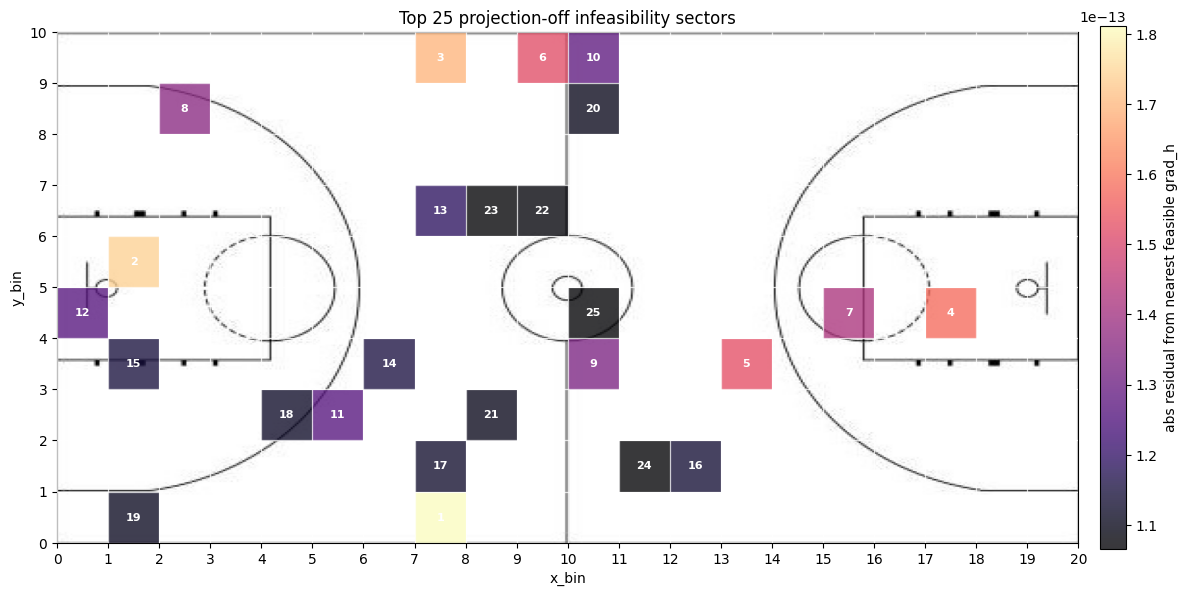

### Movement density around high-residual sectors

Compares possession-level visitation with raw movement-row density, with ranked residual sectors marked for context.

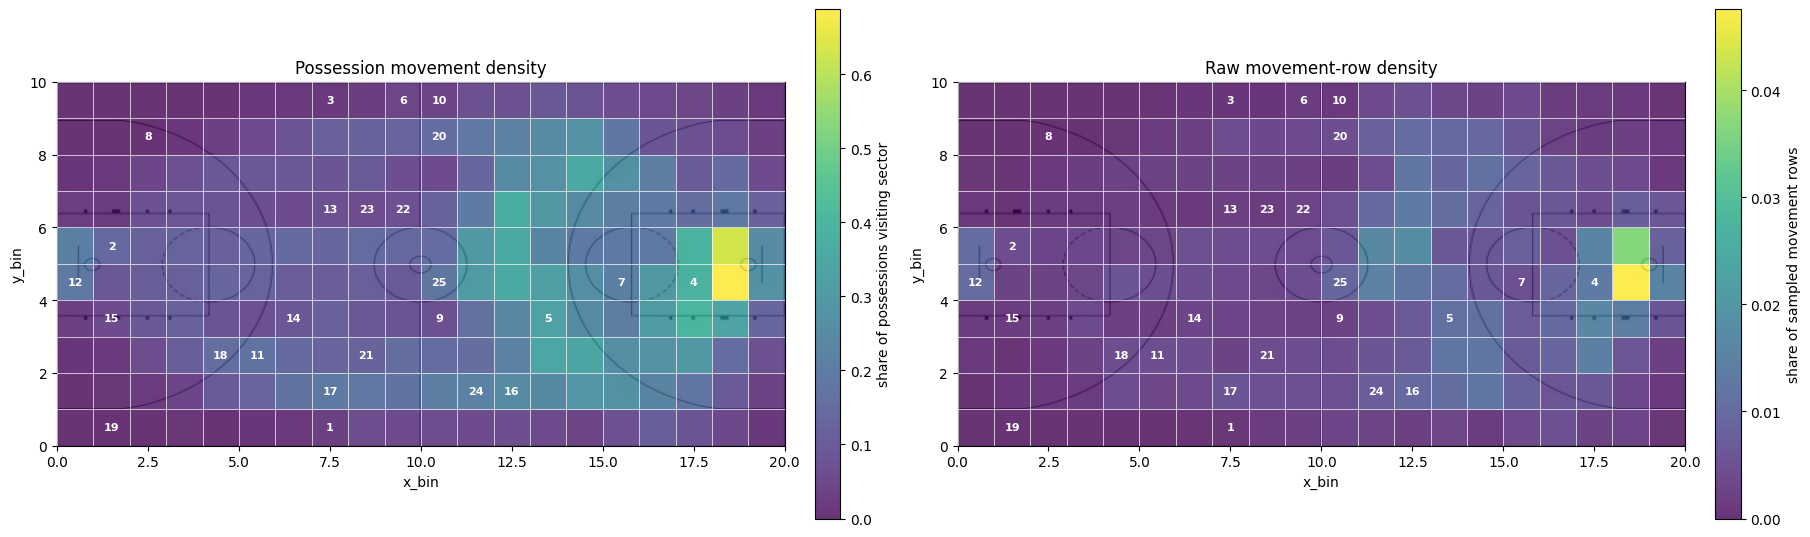

### Movement coverage and residual structure

Checks whether feasibility residuals reflect a global numerical offset or local density and gradient changes.

Interpretation: the feasibility residual is spatially uniform. For this connected TV incidence matrix,
that indicates a global zero-sum/numerical mismatch in grad_h, not a localized density gap or adjacent-sector jump.


### Feasibility-residual diagnostic summary

Summarizes the residual distribution and its rank correlations with sector density and adjacent-gradient variation.

,value
sum_grad_h,-6.821210e-13
residual_mean,-2.952638e-15
residual_std,6.585787e-14
residual_range,3.552714e-13
spearman_abs_residual_vs_possession_density,-9.835342e-02
spearman_abs_residual_vs_adjacent_grad_jump,-1.848454e-01


Calculating bootstrap QUT feasibility: 100%|██████████| 500/500 [01:02<00:00,  8.02it/s]


...

### Full-grid bounded slack

Runs null simulation, bootstrap threshold estimation, fitted coefficient mapping, and pointwise uncertainty analysis for this method.

Full-grid bounded slack
Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
lambda_qut (95th percentile null): 14.9304
lambda_max (data): 37.2142
observed feasibility adjustment L_inf: 1.39354e-08
observed solve solver: CLARABEL


Full-grid bounded slack: bootstrap lambda_max: 100%|██████████| 499/499 [01:06<00:00,  7.55it/s]

lambda_qut (95th percentile null): 14.9304
lambda_max (observed): 37.2142
95% CI for lambda_max (bootstrap): [30.5178, 43.9298]
Empirical p-value (lambda_max > lambda_qut): 0.0000


### Full-grid bounded slack — bootstrap and null lambda_max

Compares the sampling and null distributions and marks lambda_qut and the observed lambda_max.

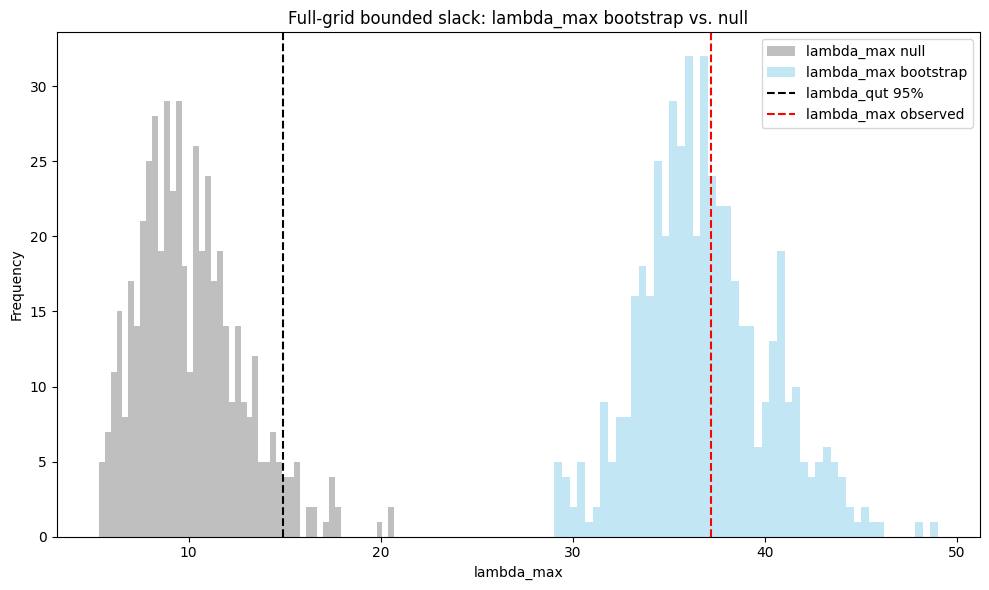

Full-grid bounded slack: pointwise maps at lambda=14.9304


Pointwise maps at fixed lambda: 100%|██████████| 500/500 [01:38<00:00,  5.07it/s]


### Full-grid bounded slack — pointwise bootstrap coefficient intervals

Maps lower, median, and upper fixed-penalty bootstrap coefficients to show sector-level uncertainty.

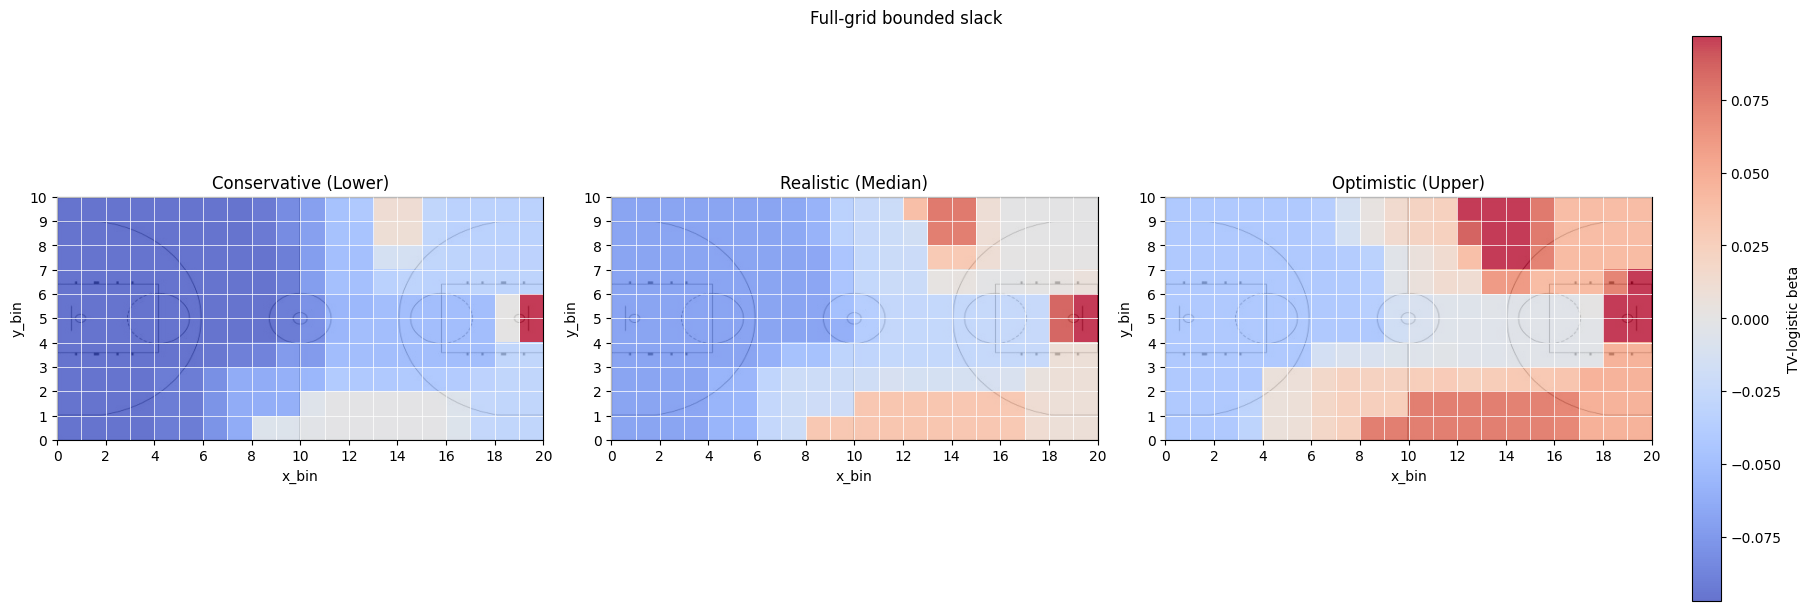

### Full-grid Moore-Penrose projection

Runs null simulation, bootstrap threshold estimation, fitted coefficient mapping, and pointwise uncertainty analysis for this method.

Full-grid Moore-Penrose projection
Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
lambda_qut (95th percentile null): 14.9304
lambda_max (data): 37.2142
observed feasibility adjustment L_inf: 1.53655e-13
observed solve solver: CLARABEL


Full-grid Moore-Penrose projection: bootstrap lambda_max: 100%|██████████| 499/499 [01:01<00:00,  8.11it/s]

lambda_qut (95th percentile null): 14.9304
lambda_max (observed): 37.2142
95% CI for lambda_max (bootstrap): [30.5178, 43.9298]
Empirical p-value (lambda_max > lambda_qut): 0.0000


### Full-grid Moore-Penrose projection — bootstrap and null lambda_max

Compares the sampling and null distributions and marks lambda_qut and the observed lambda_max.

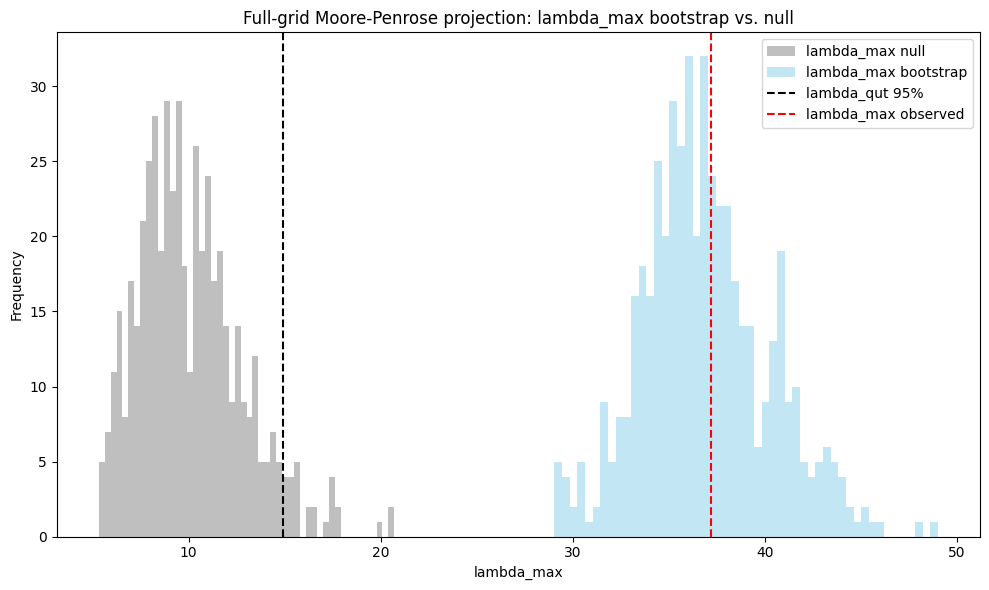

Full-grid Moore-Penrose projection: pointwise maps at lambda=14.9304


Pointwise maps at fixed lambda: 100%|██████████| 500/500 [01:38<00:00,  5.08it/s]


### Full-grid Moore-Penrose projection — pointwise bootstrap coefficient intervals

Maps lower, median, and upper fixed-penalty bootstrap coefficients to show sector-level uncertainty.

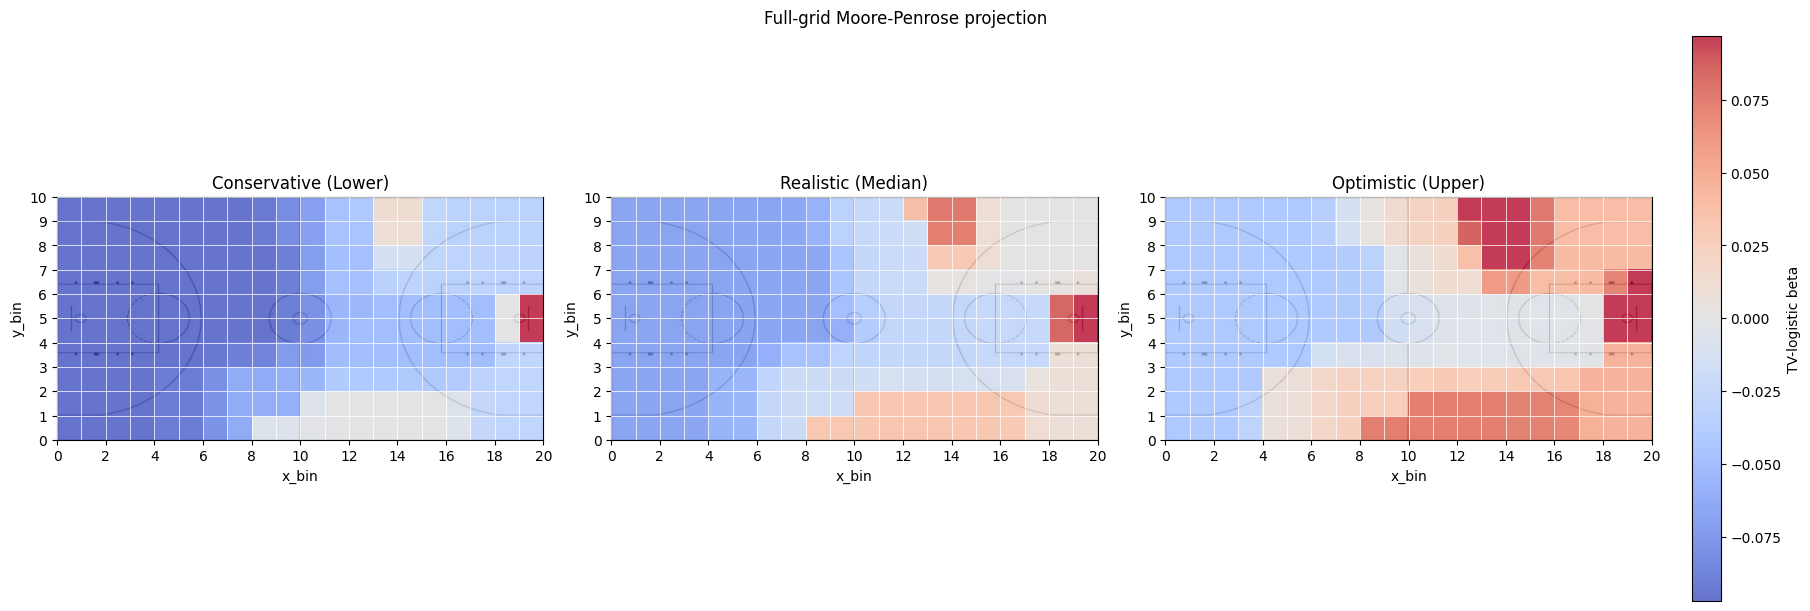

### Sector removal (<10 visits + feasibility) with bounded slack

Runs null simulation, bootstrap threshold estimation, fitted coefficient mapping, and pointwise uncertainty analysis for this method.

Sector removal (<10 visits + feasibility) with bounded slack
Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
lambda_qut (95th percentile null): 15.0654
lambda_max (data): 38.4809
observed feasibility adjustment L_inf: 1.37565e-08
observed solve solver: CLARABEL


Sector removal (<10 visits + feasibility) with bounded slack: bootstrap lambda_max: 100%|██████████| 499/499 [01:04<00:00,  7.75it/s]

lambda_qut (95th percentile null): 15.0654
lambda_max (observed): 38.4809
95% CI for lambda_max (bootstrap): [30.5260, 44.9336]
Empirical p-value (lambda_max > lambda_qut): 0.0000


### Sector removal (<10 visits + feasibility) with bounded slack — bootstrap and null lambda_max

Compares the sampling and null distributions and marks lambda_qut and the observed lambda_max.

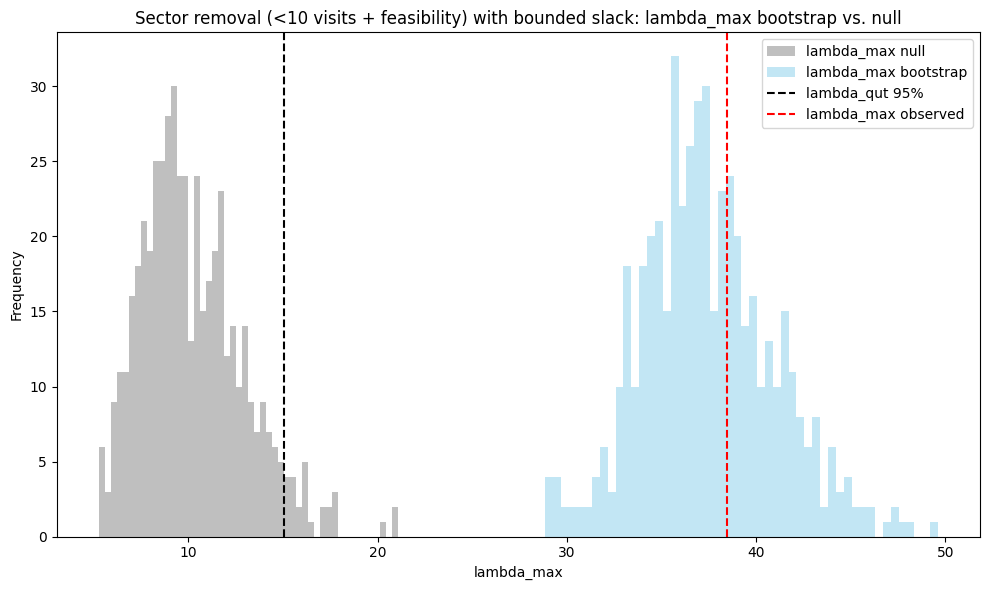

Sector removal (<10 visits + feasibility) with bounded slack: pointwise maps at lambda=15.0654


Pointwise maps at fixed lambda: 100%|██████████| 500/500 [01:37<00:00,  5.12it/s]


### Sector removal (<10 visits + feasibility) with bounded slack — pointwise bootstrap coefficient intervals

Maps lower, median, and upper fixed-penalty bootstrap coefficients to show sector-level uncertainty.

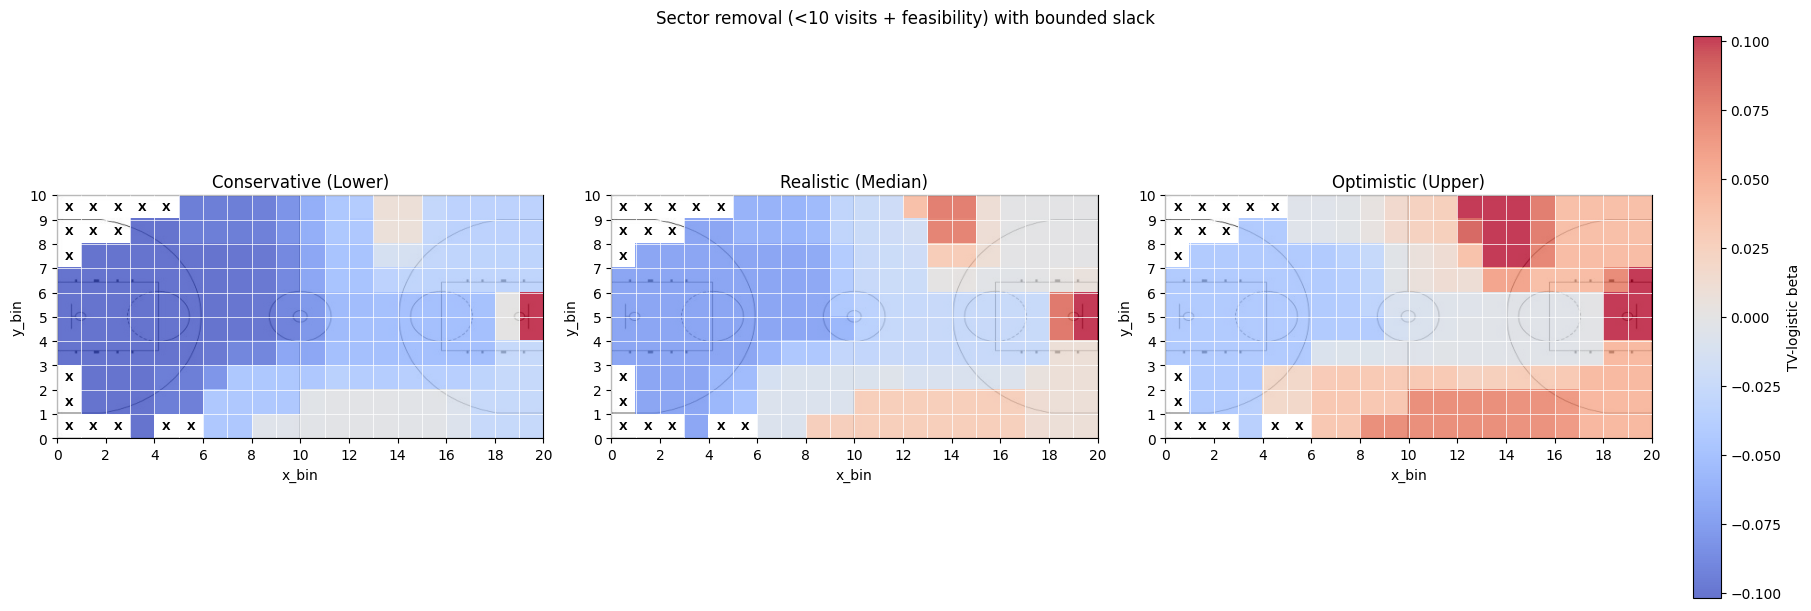

### Sector removal (<10 visits + feasibility) with Moore-Penrose projection

Runs null simulation, bootstrap threshold estimation, fitted coefficient mapping, and pointwise uncertainty analysis for this method.

Sector removal (<10 visits + feasibility) with Moore-Penrose projection
Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
lambda_qut (95th percentile null): 15.0654
lambda_max (data): 38.4809
observed feasibility adjustment L_inf: 2.70006e-13
observed solve solver: CLARABEL


Sector removal (<10 visits + feasibility) with Moore-Penrose projection: bootstrap lambda_max: 100%|██████████| 499/499 [01:01<00:00,  8.09it/s]

lambda_qut (95th percentile null): 15.0654
lambda_max (observed): 38.4809
95% CI for lambda_max (bootstrap): [30.5260, 44.9336]
Empirical p-value (lambda_max > lambda_qut): 0.0000


### Sector removal (<10 visits + feasibility) with Moore-Penrose projection — bootstrap and null lambda_max

Compares the sampling and null distributions and marks lambda_qut and the observed lambda_max.

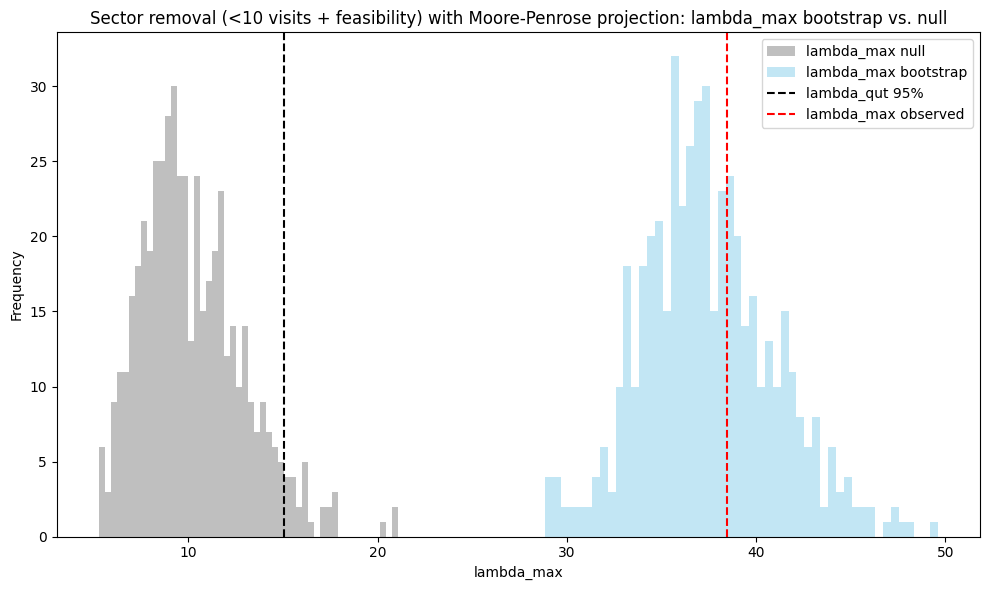

Sector removal (<10 visits + feasibility) with Moore-Penrose projection: pointwise maps at lambda=15.0654


Pointwise maps at fixed lambda: 100%|██████████| 500/500 [01:37<00:00,  5.14it/s]


### Sector removal (<10 visits + feasibility) with Moore-Penrose projection — pointwise bootstrap coefficient intervals

Maps lower, median, and upper fixed-penalty bootstrap coefficients to show sector-level uncertainty.

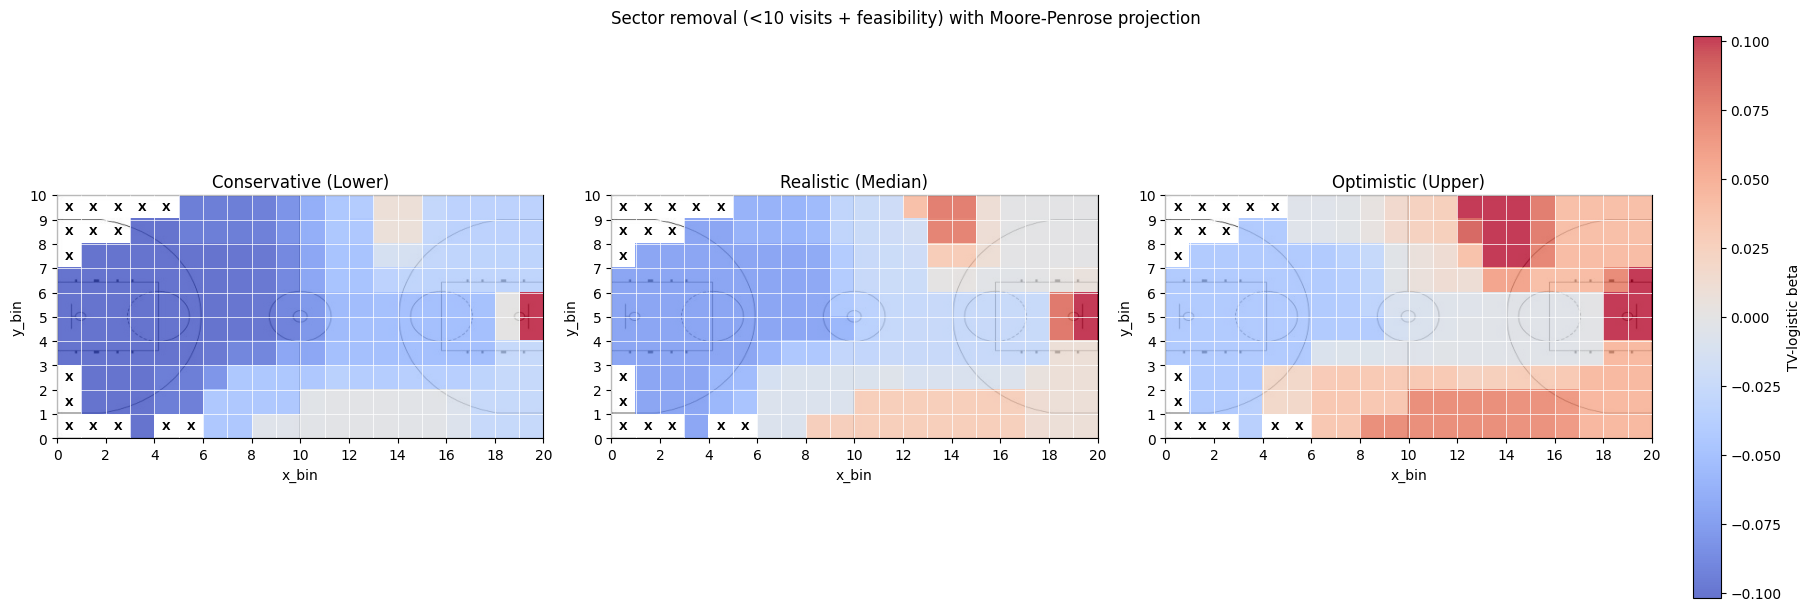

### QUT method comparison

Aggregates thresholds, bootstrap uncertainty, feasibility adjustments, and solve outcomes across all four methods.

,sectors_retained,tv_edges_retained,lambda_qut,lambda_max_observed,bootstrap_lambda_median,bootstrap_lambda_std,bootstrap_ci_lower,bootstrap_ci_upper,empirical_p_value,observed_adjustment_linf,bootstrap_adjustment_p95,successful_bootstrap_solves,failed_bootstrap_solves,successful_null_solves,failed_null_attempts,failed_pointwise_refits
method,,,,,,,,,,,,,,,,
full_grid_bounded_slack,200,370,14.9304,37.2142,36.6154,3.3353,30.5178,43.9298,0.0000,1.39354e-08,4.17683e-08,500,0,500,0,0
full_grid_moore_penrose,200,370,14.9304,37.2142,36.6154,3.3353,30.5178,43.9298,0.0000,1.53655e-13,9.43032e-09,500,0,500,0,0
sector_removal_bounded_slack,184,337,15.0654,38.4809,37.1099,3.5375,30.5260,44.9336,0.0000,1.37565e-08,3.95851e-08,500,0,500,0,0
sector_removal_moore_penrose,184,337,15.0654,38.4809,37.1099,3.5375,30.5260,44.9336,0.0000,2.70006e-13,5.59803e-09,500,0,500,0,0


### Sector coefficients across QUT methods

Uses a shared color scale to compare coefficient patterns across full and reduced grids and slack and projection corrections.

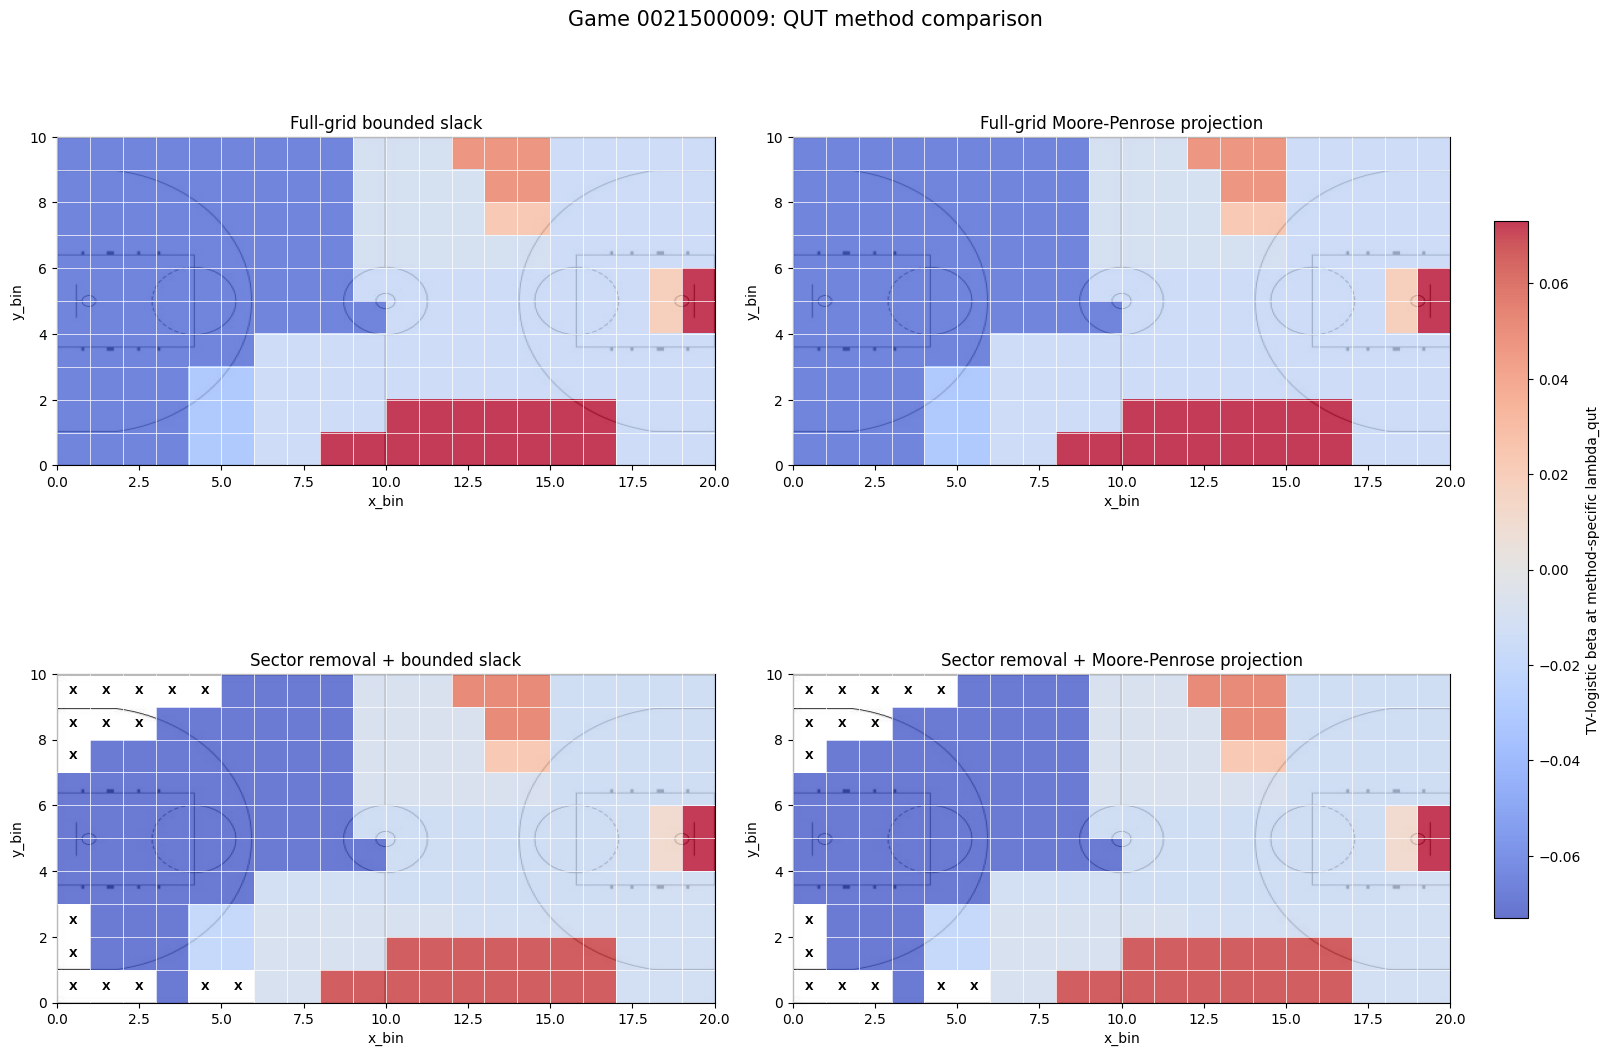

In [13]:
GAME_0021500009_RESULTS = run_game_comparison(
    game_id="0021500009",
    data_path=Path("Data/analysis_ready_half_court_filtered.csv"),
)


## Game 0021500390: four-method QUT comparison

This game uses the identical compact output contract and shared-bootstrap methodology as game 0021500009.


### Game and shared-bootstrap setup

Reports the selected game, eligible possessions, orientation checks, and the common bootstrap design used by every method.

Game: 0021500390
Loaded target-game rows: 27,323
Target-game possessions: 73
Eligible possessions (>=100 rows): 70
QUT bin orientation method: funcs.bin_and_flip_home_away_period
Possessions flipped: 37
Post-orientation mean end-start x_bin: 11.5205
Generating one shared set of target-game bootstrap datasets...


Generating Bootstrapped Datasets: 100%|██████████| 500/500 [03:28<00:00,  2.40it/s]

Shared bootstrap datasets: 500
Shared first-bootstrap rows: 100,000
Shared X shape: (1000, 200); D_TV shape: (370, 200); scored rate: 0.6110


### Full-grid null-gradient feasibility

Quantifies the raw null gradient's departure from the TV column space before any feasibility treatment.

null beta0: 0.0133610069993
null penalty: None
null optimizer iterations: 4
null likelihood score: 1.97447e-08
sum(grad_h): 1.9744e-08
non-representable constant offset: 9.872e-11
Distance from grad_h to col(D_TV.T): L2=1.39611e-09, Linf=9.90399e-11
rank(D_TV.T)=199 / 200 variables


### Locations of the largest feasibility residuals

Ranked labels locate the highest-residual sectors on the court, while color shows absolute residual magnitude.

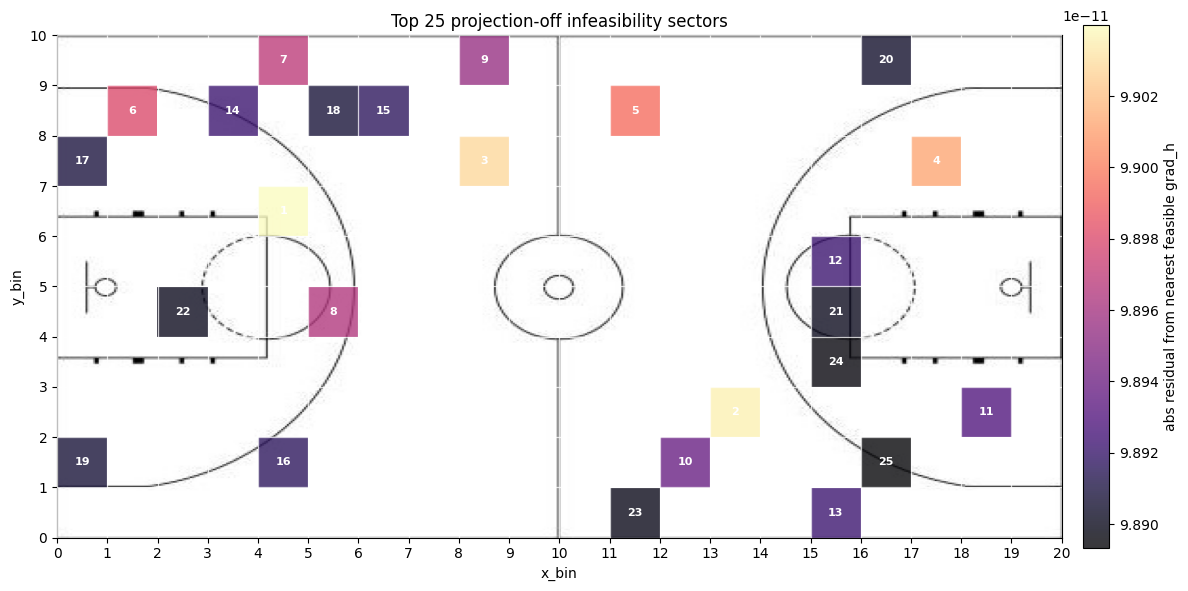

### Movement density around high-residual sectors

Compares possession-level visitation with raw movement-row density, with ranked residual sectors marked for context.

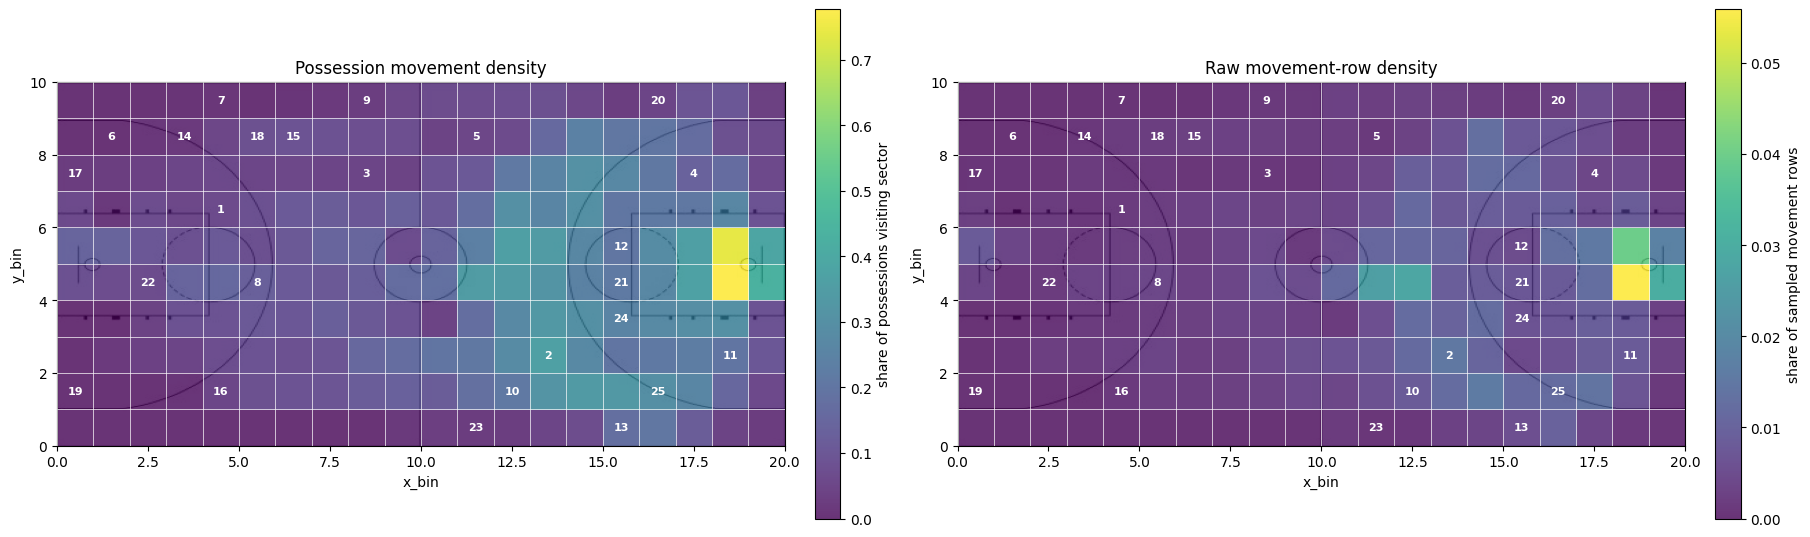

### Movement coverage and residual structure

Checks whether feasibility residuals reflect a global numerical offset or local density and gradient changes.

Interpretation: the feasibility residual is spatially uniform. For this connected TV incidence matrix,
that indicates a global zero-sum/numerical mismatch in grad_h, not a localized density gap or adjacent-sector jump.


### Feasibility-residual diagnostic summary

Summarizes the residual distribution and its rank correlations with sector density and adjacent-gradient variation.

,value
sum_grad_h,1.974399e-08
residual_mean,9.872010e-11
residual_std,1.407510e-13
residual_range,6.910028e-13
spearman_abs_residual_vs_possession_density,-5.289712e-02
spearman_abs_residual_vs_adjacent_grad_jump,-5.308271e-02


Calculating bootstrap QUT feasibility: 100%|██████████| 500/500 [01:04<00:00,  7.80it/s]


...

### Full-grid bounded slack

Runs null simulation, bootstrap threshold estimation, fitted coefficient mapping, and pointwise uncertainty analysis for this method.

Full-grid bounded slack
Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
lambda_qut (95th percentile null): 15.7173
lambda_max (data): 59.8711
observed feasibility adjustment L_inf: 8.364e-09
observed solve solver: CLARABEL


Full-grid bounded slack: bootstrap lambda_max: 100%|██████████| 499/499 [01:11<00:00,  7.02it/s]

lambda_qut (95th percentile null): 15.7173
lambda_max (observed): 59.8711
95% CI for lambda_max (bootstrap): [47.4160, 62.4680]
Empirical p-value (lambda_max > lambda_qut): 0.0000


### Full-grid bounded slack — bootstrap and null lambda_max

Compares the sampling and null distributions and marks lambda_qut and the observed lambda_max.

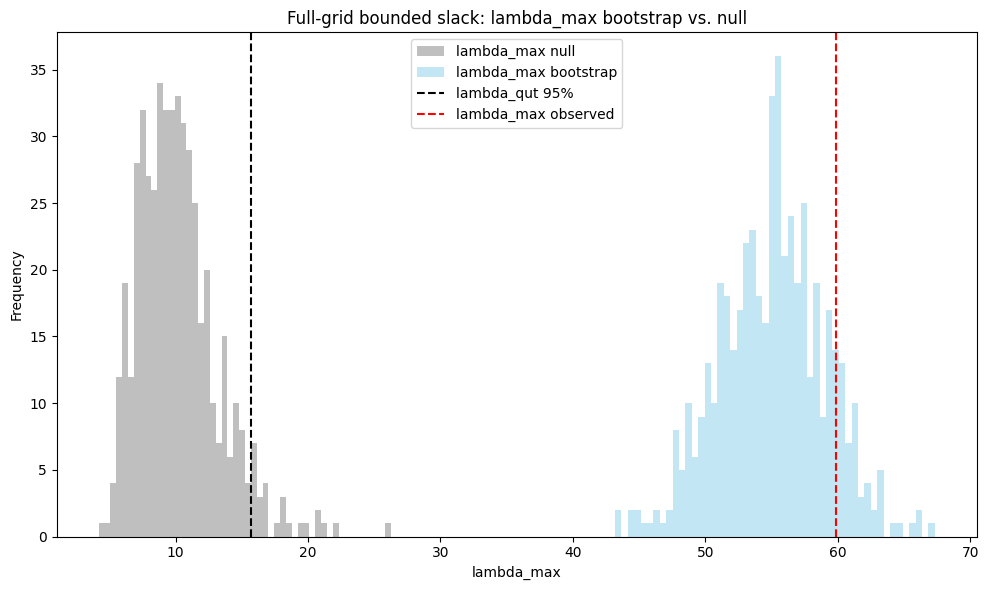

Full-grid bounded slack: pointwise maps at lambda=15.7173


Pointwise maps at fixed lambda: 100%|██████████| 500/500 [01:45<00:00,  4.76it/s]


### Full-grid bounded slack — pointwise bootstrap coefficient intervals

Maps lower, median, and upper fixed-penalty bootstrap coefficients to show sector-level uncertainty.

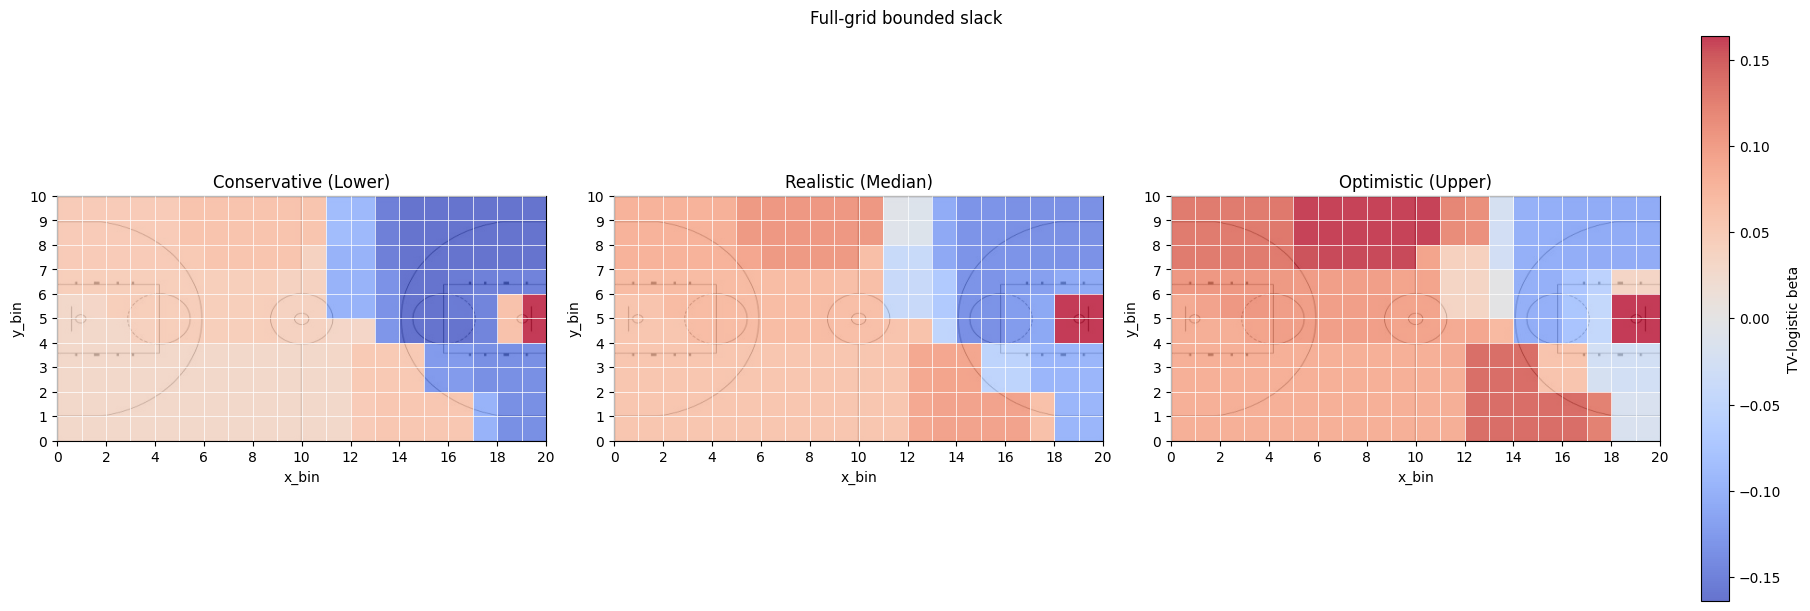

### Full-grid Moore-Penrose projection

Runs null simulation, bootstrap threshold estimation, fitted coefficient mapping, and pointwise uncertainty analysis for this method.

Full-grid Moore-Penrose projection
Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
lambda_qut (95th percentile null): 15.7173
lambda_max (data): 59.8711
observed feasibility adjustment L_inf: 9.89786e-11
observed solve solver: CLARABEL


Full-grid Moore-Penrose projection: bootstrap lambda_max: 100%|██████████| 499/499 [01:05<00:00,  7.61it/s]

lambda_qut (95th percentile null): 15.7173
lambda_max (observed): 59.8711
95% CI for lambda_max (bootstrap): [47.4160, 62.4680]
Empirical p-value (lambda_max > lambda_qut): 0.0000


### Full-grid Moore-Penrose projection — bootstrap and null lambda_max

Compares the sampling and null distributions and marks lambda_qut and the observed lambda_max.

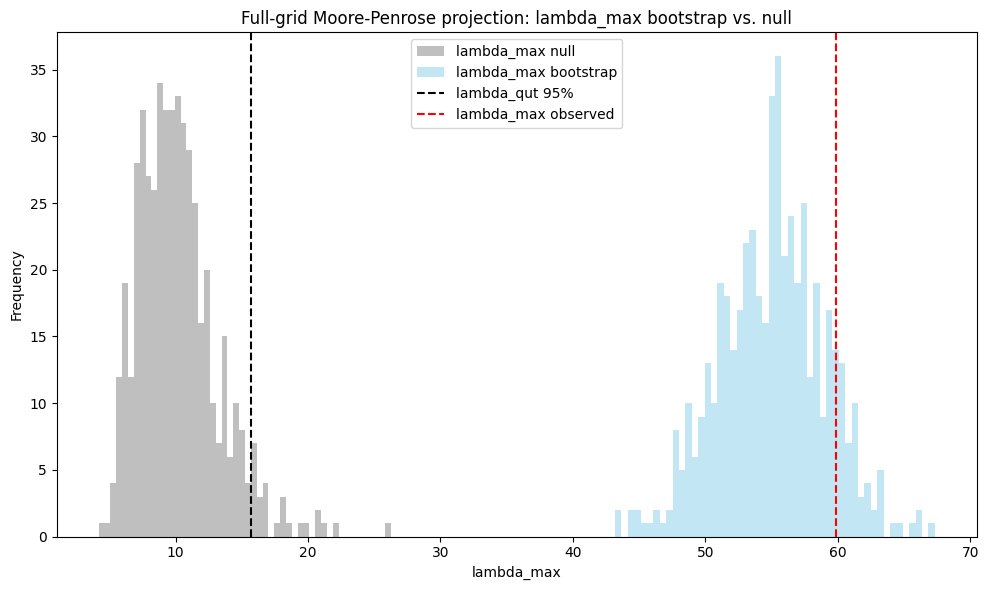

Full-grid Moore-Penrose projection: pointwise maps at lambda=15.7173


Pointwise maps at fixed lambda: 100%|██████████| 500/500 [01:41<00:00,  4.93it/s]


### Full-grid Moore-Penrose projection — pointwise bootstrap coefficient intervals

Maps lower, median, and upper fixed-penalty bootstrap coefficients to show sector-level uncertainty.

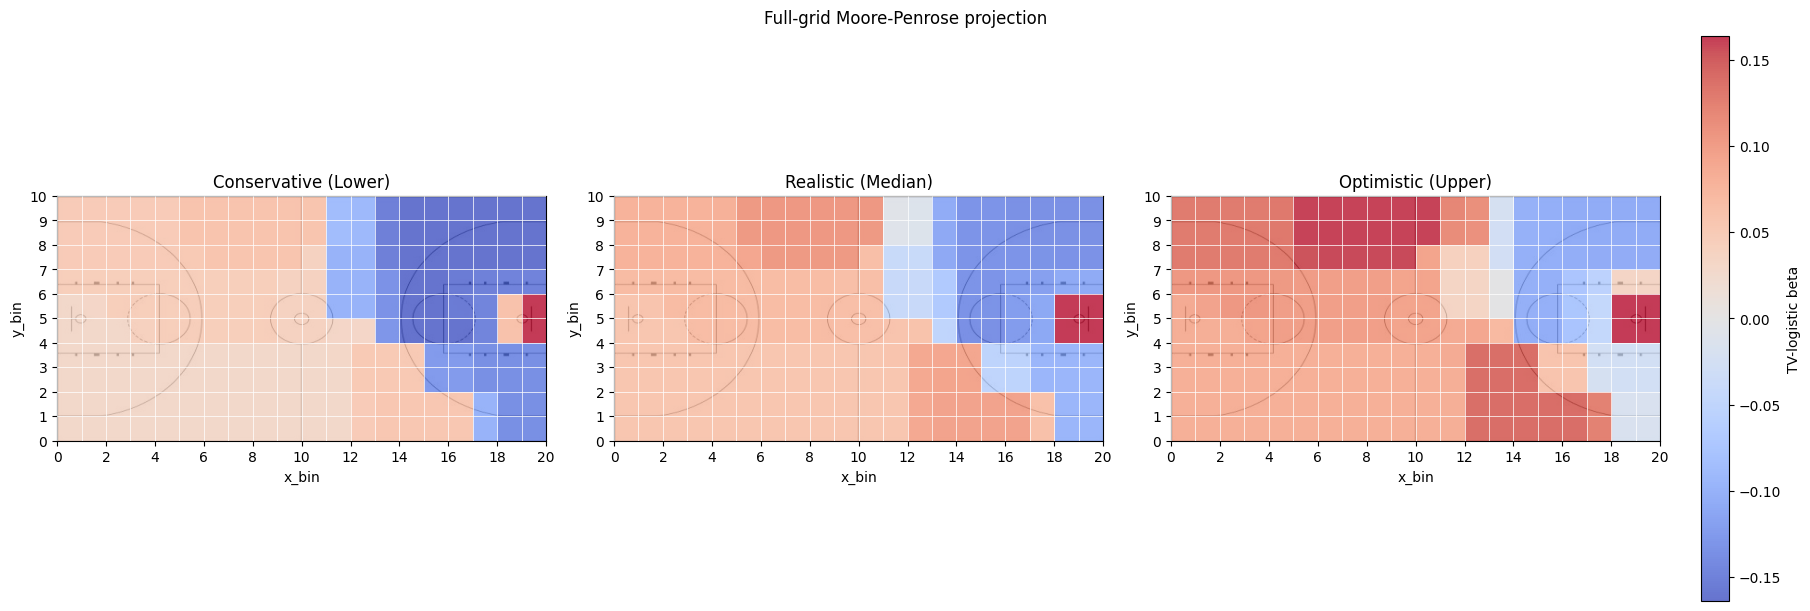

### Sector removal (<10 visits + feasibility) with bounded slack

Runs null simulation, bootstrap threshold estimation, fitted coefficient mapping, and pointwise uncertainty analysis for this method.

Sector removal (<10 visits + feasibility) with bounded slack
Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
lambda_qut (95th percentile null): 15.8729
lambda_max (data): 59.8417
observed feasibility adjustment L_inf: 8.32406e-09
observed solve solver: CLARABEL


Sector removal (<10 visits + feasibility) with bounded slack: bootstrap lambda_max: 100%|██████████| 499/499 [01:06<00:00,  7.51it/s]

lambda_qut (95th percentile null): 15.8729
lambda_max (observed): 59.8417
95% CI for lambda_max (bootstrap): [47.4086, 62.4109]
Empirical p-value (lambda_max > lambda_qut): 0.0000


### Sector removal (<10 visits + feasibility) with bounded slack — bootstrap and null lambda_max

Compares the sampling and null distributions and marks lambda_qut and the observed lambda_max.

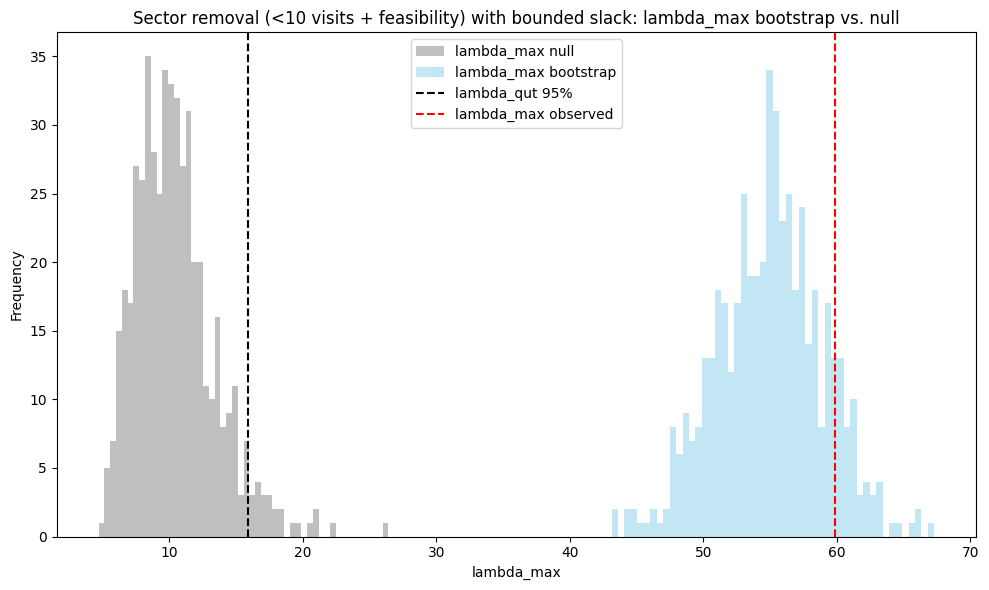

Sector removal (<10 visits + feasibility) with bounded slack: pointwise maps at lambda=15.8729


Pointwise maps at fixed lambda: 100%|██████████| 500/500 [01:36<00:00,  5.15it/s]


### Sector removal (<10 visits + feasibility) with bounded slack — pointwise bootstrap coefficient intervals

Maps lower, median, and upper fixed-penalty bootstrap coefficients to show sector-level uncertainty.

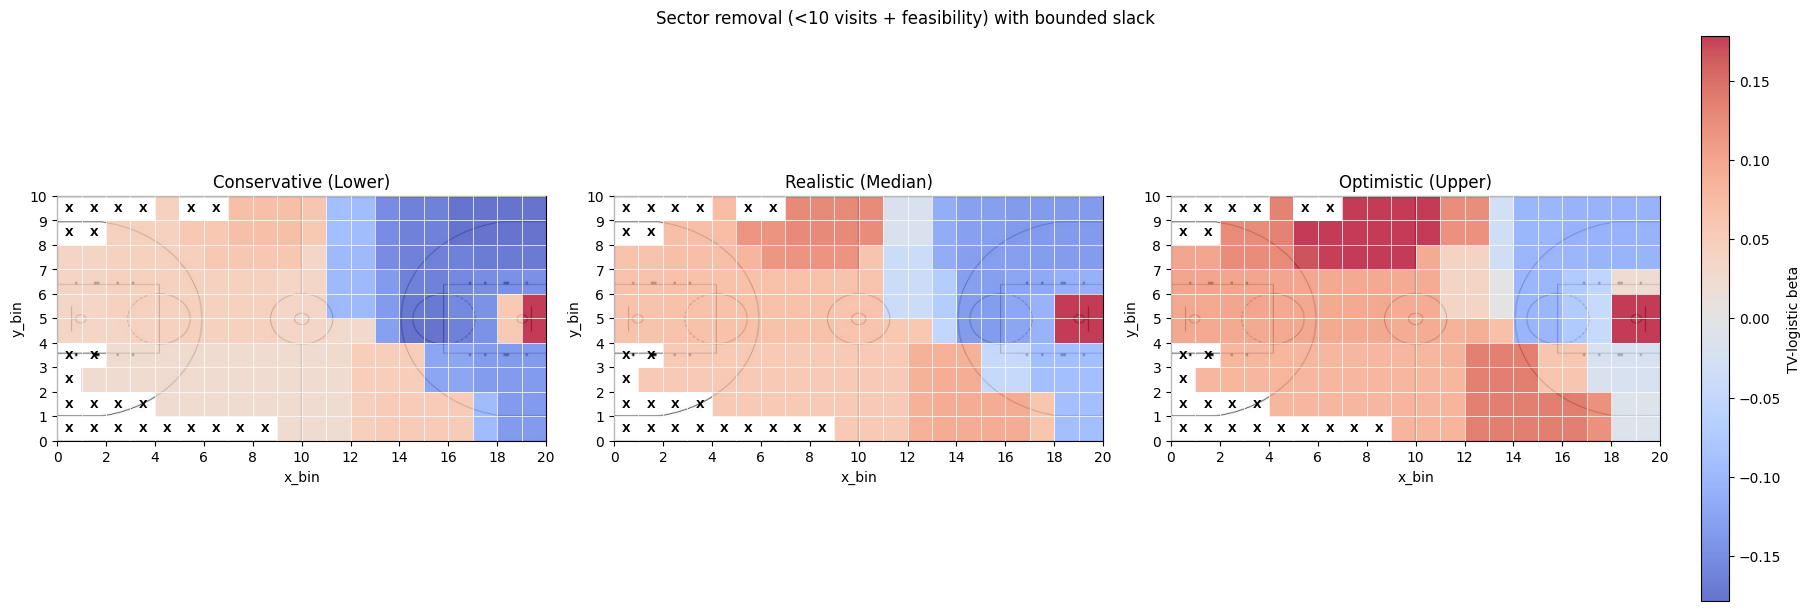

### Sector removal (<10 visits + feasibility) with Moore-Penrose projection

Runs null simulation, bootstrap threshold estimation, fitted coefficient mapping, and pointwise uncertainty analysis for this method.

Sector removal (<10 visits + feasibility) with Moore-Penrose projection
Simulating null responses...
Accepted 100 / 500 simulations
Accepted 200 / 500 simulations
Accepted 300 / 500 simulations
Accepted 400 / 500 simulations
Accepted 500 / 500 simulations
lambda_qut (95th percentile null): 15.8729
lambda_max (data): 59.8417
observed feasibility adjustment L_inf: 1.11827e-10
observed solve solver: CLARABEL


Sector removal (<10 visits + feasibility) with Moore-Penrose projection: bootstrap lambda_max: 100%|██████████| 499/499 [01:00<00:00,  8.25it/s]

lambda_qut (95th percentile null): 15.8729
lambda_max (observed): 59.8417
95% CI for lambda_max (bootstrap): [47.4086, 62.4109]
Empirical p-value (lambda_max > lambda_qut): 0.0000


### Sector removal (<10 visits + feasibility) with Moore-Penrose projection — bootstrap and null lambda_max

Compares the sampling and null distributions and marks lambda_qut and the observed lambda_max.

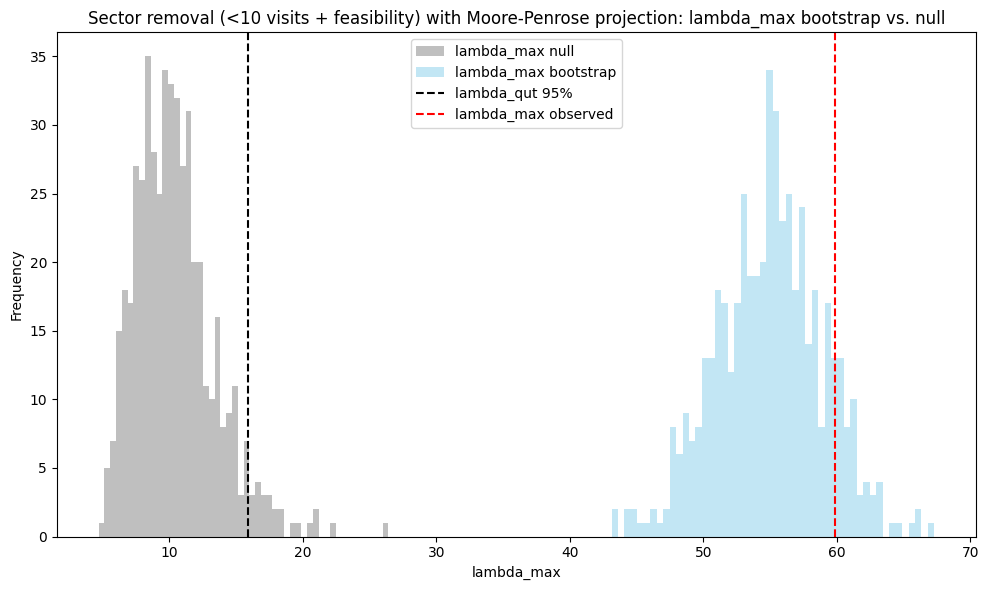

Sector removal (<10 visits + feasibility) with Moore-Penrose projection: pointwise maps at lambda=15.8729


Pointwise maps at fixed lambda: 100%|██████████| 500/500 [01:35<00:00,  5.22it/s]


### Sector removal (<10 visits + feasibility) with Moore-Penrose projection — pointwise bootstrap coefficient intervals

Maps lower, median, and upper fixed-penalty bootstrap coefficients to show sector-level uncertainty.

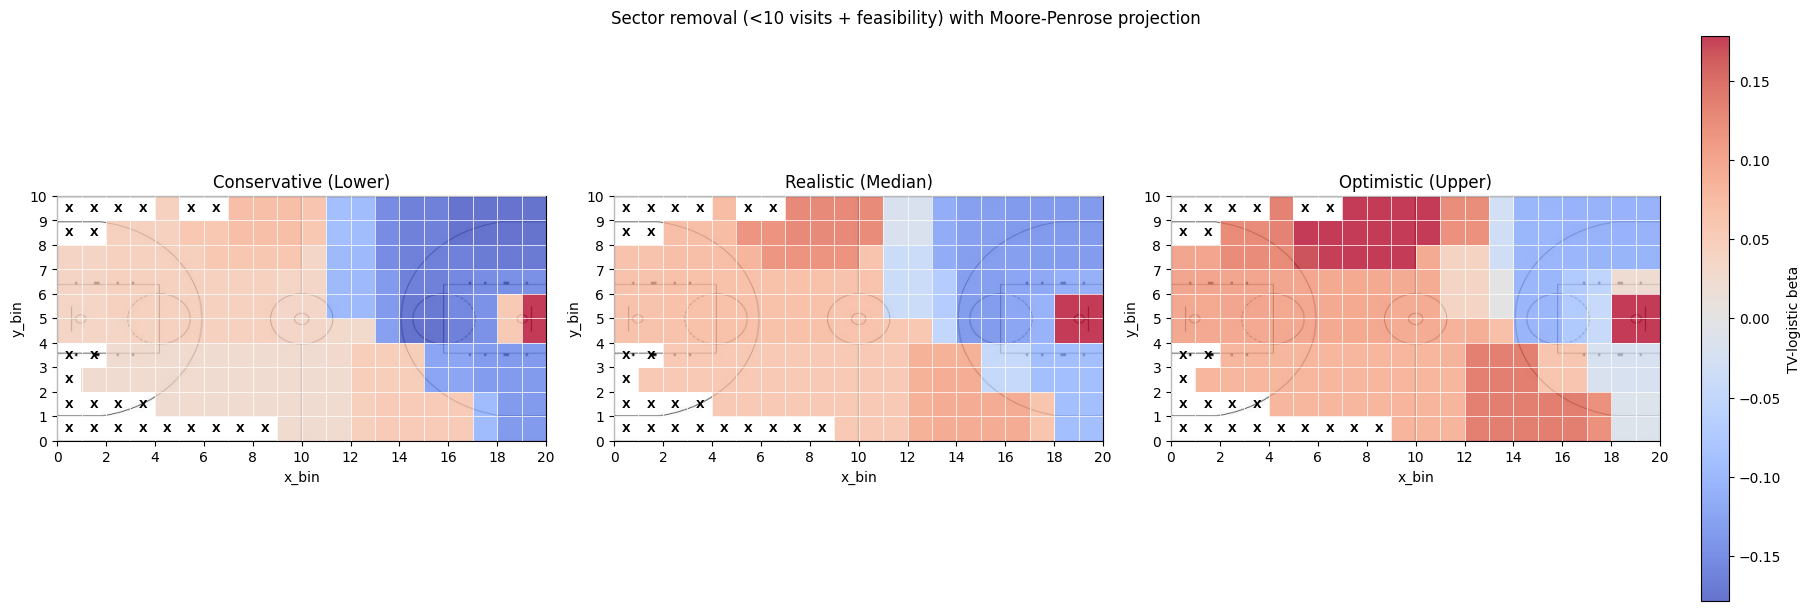

### QUT method comparison

Aggregates thresholds, bootstrap uncertainty, feasibility adjustments, and solve outcomes across all four methods.

,sectors_retained,tv_edges_retained,lambda_qut,lambda_max_observed,bootstrap_lambda_median,bootstrap_lambda_std,bootstrap_ci_lower,bootstrap_ci_upper,empirical_p_value,observed_adjustment_linf,bootstrap_adjustment_p95,successful_bootstrap_solves,failed_bootstrap_solves,successful_null_solves,failed_null_attempts,failed_pointwise_refits
method,,,,,,,,,,,,,,,,
full_grid_bounded_slack,200,370,15.7173,59.8711,55.1445,3.9841,47.4160,62.4680,0.0000,8.364e-09,2.50339e-08,500,0,500,0,0
full_grid_moore_penrose,200,370,15.7173,59.8711,55.1445,3.9841,47.4160,62.4680,0.0000,9.89786e-11,4.23108e-10,500,0,500,0,0
sector_removal_bounded_slack,176,320,15.8729,59.8417,55.0644,3.9871,47.4086,62.4109,0.0000,8.32406e-09,2.44054e-08,500,0,500,0,0
sector_removal_moore_penrose,176,320,15.8729,59.8417,55.0644,3.9871,47.4086,62.4109,0.0000,1.11827e-10,4.49624e-10,500,0,500,0,0


### Sector coefficients across QUT methods

Uses a shared color scale to compare coefficient patterns across full and reduced grids and slack and projection corrections.

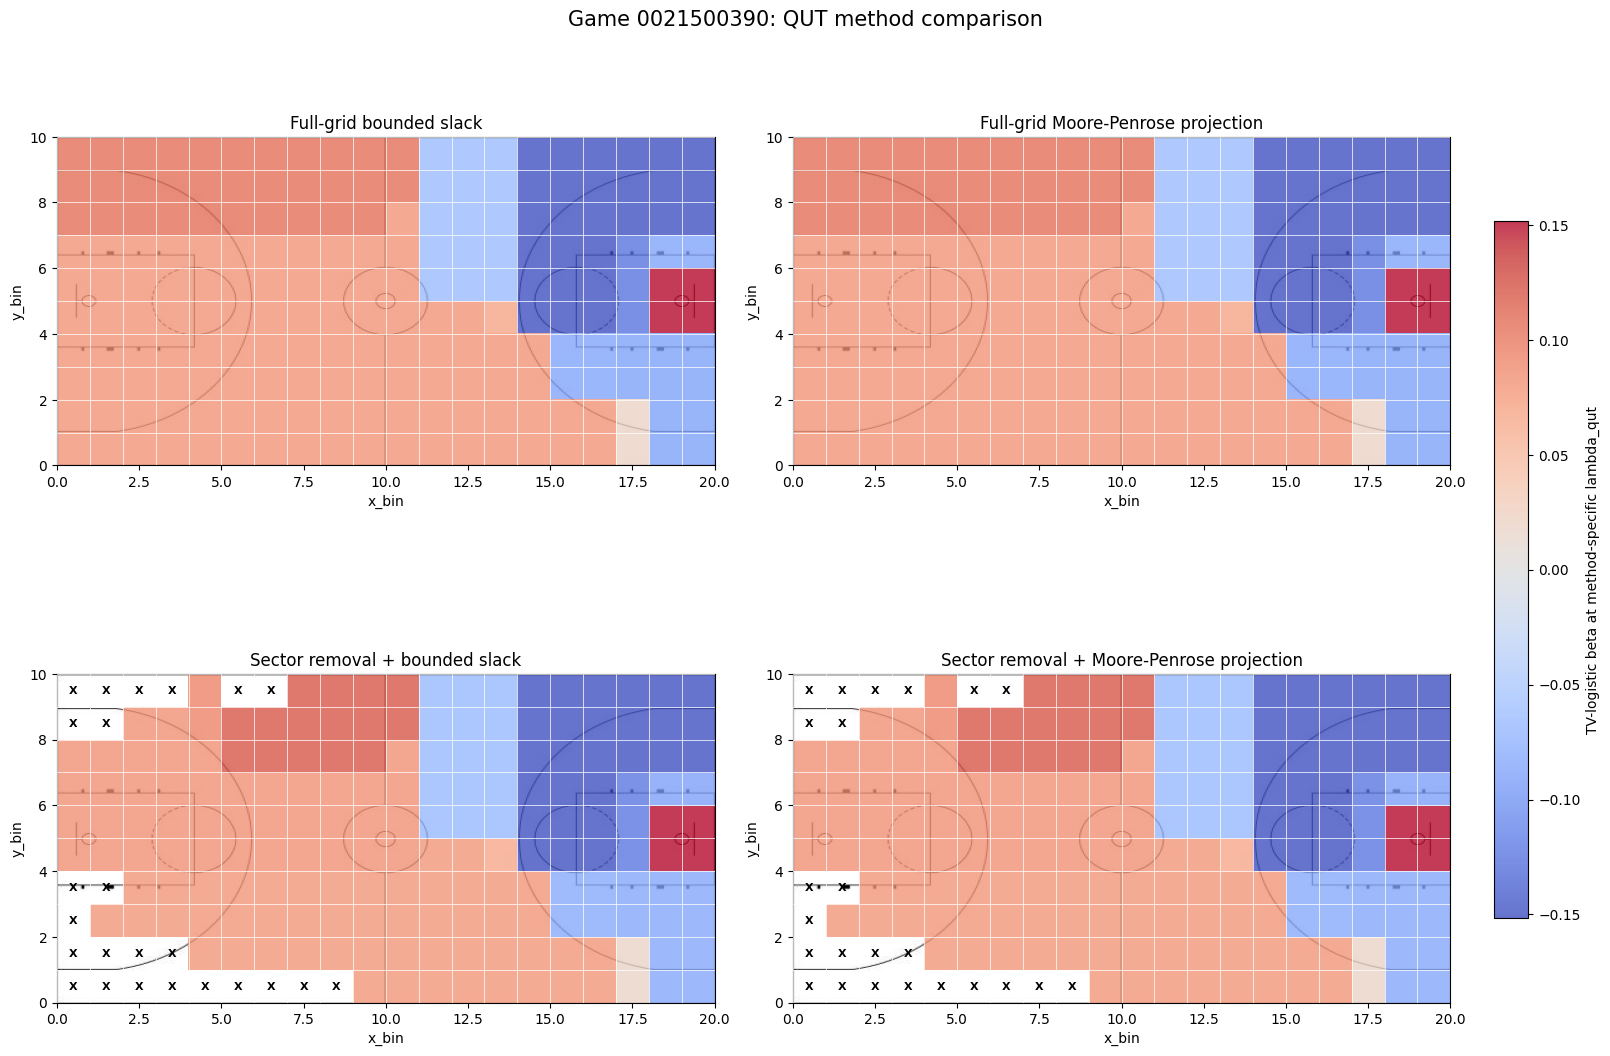

In [14]:
GAME_0021500390_RESULTS = run_game_comparison(
    game_id="0021500390",
    data_path=Path("multi_game_data/multi_game_data_half_court_filtered.csv"),
)
